# EOL Measurement System Analysis with ANOVA and Decision Risk

## Introduction

End-of-Line (EOL) testing systems are widely used in industrial environments to make rapid Pass/Fail decisions based on measured product characteristics such as pressure and airflow. Since these decisions directly affect product release, it is important to understand whether the measurement system is stable, consistent, and comparable to an external reference setup.

This project investigates a simulated industrial scenario in which measurements from an EOL test machine are compared with measurements from an external parallel setup using a pressure meter and an airflow meter. The analysis combines data processing, exploratory data analysis, probability density functions, hypothesis testing, ANOVA, decision-risk evaluation, and drift analysis over time.

The main goal is not only to detect statistical differences between the two measurement sources, but also to determine whether these differences can influence real production decisions.

## Problem Definition

In industrial testing, automated EOL systems are often used as the final decision point for product acceptance. However, the measured values produced by the EOL machine may differ from those obtained from external instruments due to measurement variation, channel effects, bias, and drift over time.

This creates an important engineering question:

**Can differences between the EOL machine and an external parallel measurement setup lead to statistically significant deviations and practically important false Pass / false Fail decisions?**

To study this problem, this project compares paired measurements from two independent data sources:
1. the EOL test machine
2. an external setup consisting of a CEM DT-8890 pressure meter and a TSI 5200 airflow meter

## Project Objective

The objective of this project is to evaluate the agreement between an End-of-Line test machine and an external parallel measurement setup by using statistical analysis and data science methods.

More specifically, the project aims to:
- compare pressure and airflow measurements from two independent sources
- assess whether the observed differences are statistically significant
- evaluate whether these differences can produce false Pass / false Fail decisions
- analyze whether measurement behavior changes over time
- present all steps in a reproducible research workflow

## Research Questions

This project is guided by the following research questions:

1. Is there a statistically significant difference between the measurements from the EOL system and the external parallel setup?
2. Do different EOL channels behave differently?
3. Can measurement differences between the two sources lead to false Pass or false Fail decisions?
4. Is there evidence of measurement drift over time?
5. Are the detected differences only statistically significant, or also practically important for production testing?

## Data Sources

The analysis is based on two independent data sources:

### Source 1: EOL machine
The first data source represents measurements collected from the End-of-Line test machine. These data include pressure, airflow-related values, channel information, timestamps, and Pass/Fail decisions.

### Source 2: External parallel setup
The second data source represents measurements collected in parallel from external instruments:
- **CEM DT-8890** pressure meter
- **TSI 5200** airflow meter

These external measurements are used as a practical reference for comparison with the EOL machine.

## Epistemic Hygiene

This project uses logically constructed synthetic data designed to reflect a realistic industrial testing scenario. The dataset is intended for educational and analytical purposes and does not claim to represent certified production data.

The external setup is treated as a practical reference for comparison, but not as absolute ground truth in the strict metrological sense. Therefore, all conclusions in this notebook should be interpreted within the assumptions, thresholds, and simulated operating conditions used in the analysis.

In addition, statistical significance will be interpreted separately from practical engineering significance.

## Reproducible Research

This project follows reproducible research principles. All steps for data generation, validation, processing, analysis, and visualization will be performed in a single Jupyter notebook using Python.

The notebook will be designed to run from top to bottom, with fixed random seeds where needed, clear section separation, and consistent variable naming. This approach helps ensure that the results can be reproduced and reviewed in a transparent way.

## Module Topics Covered

This project is designed to integrate the following topics from the Data Science module:

- Working with Data
- Data Visualization. Exploratory Data Analysis
- Hypothesis Testing
- Working with Images
- Working with Text

In [35]:
project_title = "EOL Measurement System Analysis with ANOVA and Decision Risk"
print(project_title)

EOL Measurement System Analysis with ANOVA and Decision Risk


## Project Scope

This project focuses on the comparison of paired measurements collected from two independent data sources: the End-of-Line testing system and an external parallel measurement setup.

The analysis is limited to pressure and airflow measurements generated under controlled, simulated industrial conditions. The project includes:
- data generation and validation
- data consolidation and comparison
- exploratory data analysis
- probability density function (PDF) interpretation
- hypothesis testing
- ANOVA-based comparison
- false Pass / false Fail analysis
- drift analysis over time

Calibration traceability, physical sensor modeling, and formal uncertainty budgeting are outside the scope of this work.

## Hypotheses

The main statistical hypothesis in this project is:

**Null hypothesis (H0):**  
There is no statistically significant difference in the mean measured values between the EOL machine and the external parallel measurement setup.

**Alternative hypothesis (H1):**  
There is a statistically significant difference in the mean measured values between the EOL machine and the external parallel measurement setup.

Additional comparisons in the project may also evaluate:
- channel-related effects
- time-related effects
- interaction between measurement source and channel
- interaction between measurement source and time

## Planned Variables

The synthetic dataset will be designed to include logically structured variables such as:

- sample_id
- batch_id
- timestamp
- day
- channel
- operator
- eol_pressure_mmhg
- ext_pressure_mmhg
- eol_flow_lmin
- ext_flow_lmin
- pressure_bias
- flow_bias
- eol_decision
- reference_decision
- false_pass
- false_fail

These variables will allow comparison between the two measurement sources, statistical testing, and decision-risk analysis.

## Notebook Roadmap

The notebook is organized into the following main sections:

1. Introduction  
2. Problem Definition  
3. Project Objective  
4. Research Questions  
5. Data Sources  
6. Epistemic Hygiene  
7. Reproducible Research  
8. Module Topics Covered  
9. Project Scope  
10. Hypotheses  
11. Planned Variables  
12. Working with Data  
13. Data Cleaning and Validation  
14. Data Visualization and Exploratory Data Analysis  
15. Probability Density Function (PDF) Analysis  
16. Hypothesis Testing  
17. ANOVA Analysis  
18. False Pass / False Fail Analysis  
19. Drift Analysis Over Time  
20. Working with Images  
21. Working with Text  
22. Limitations  
23. Conclusion  
24. References

In [40]:
day = 1
status = "Project framing completed"
print(f"Day {day}: {status}")

Day 1: Project framing completed


## Day 2 Objective

The objective of Day 2 is to design and generate a structured synthetic dataset representing paired measurements from two independent sources:
1. an End-of-Line (EOL) measurement system
2. an external parallel measurement setup

The dataset will be constructed to reflect realistic industrial behavior, including normal variation, channel effects, small source differences, borderline cases near the decision threshold, and mild drift over time.

I want enough data for ANOVA, decision analysis, and drift analysis, but not so much that it becomes messy.
Proposed structure
10 days
4 EOL channels
12 samples per channel per day
So total paired observations:
10 × 4 × 12 = 480 observations

## Main measured variables

Pressure in mmHg
Airflow in L/min

from two sources:

EOL
External connected in parallel to the test product

So the paired variables will be:

eol_pressure_mmhg
ext_pressure_mmhg
eol_flow_lmin
ext_flow_lmin

## Synthetic Data Assumptions

The synthetic dataset is based on the following engineering assumptions:

- The product is evaluated using pressure and airflow-related measurements.
- The external setup is used as a practical reference.
- The EOL system is expected to be close to the external system, but not identical.
- Different EOL channels may have slightly different behavior.
- Some measurements are intentionally generated near the decision limit in order to study false pass / false fail outcomes.
- Mild drift is introduced during the last part of the study period to simulate gradual system change over time.

Acceptance creteria
Pass if measured pressure >= 54 mmHg
Fail if measured pressure < 54 mmHg
Visual the test product should now has any geometry deformation
EOL should differ slightly from external:
small average bias, for example around +0.3 mmHg or -0.4 mmHg
Each channel behaves a bit differently, for example:

Channel 1: neutral
Channel 2: slight positive bias
Channel 3: slight negative bias
Channel 4: slightly larger variation


## Final Dataset Variables

The synthetic dataset will include the following variables:

- sample_id
- day
- channel
- batch_id
- operator
- true_pressure_mmhg
- true_flow_lmin
- ext_pressure_mmhg
- eol_pressure_mmhg
- ext_flow_lmin
- eol_flow_lmin
- pressure_bias
- flow_bias
- reference_decision
- eol_decision
- false_pass
- false_fail

In [9]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_days = 10
channels = [1, 2, 3, 4]
samples_per_channel_per_day = 12

total_observations = n_days * len(channels) * samples_per_channel_per_day
print("Total observations:", total_observations)

Total observations: 480


In [11]:
rows = []

sample_counter = 1

for day in range(1, n_days + 1):
    for channel in channels:
        for sample_in_day in range(1, samples_per_channel_per_day + 1):
            rows.append({
                "sample_id": f"S{sample_counter:03d}",
                "day": day,
                "channel": channel,
                "batch_id": f"B{day:02d}",
                "operator": np.random.choice(["Op_A", "Op_B", "Op_C"])
            })
            sample_counter += 1

df = pd.DataFrame(rows)
df.head()

,sample_id,day,channel,batch_id,operator
0,S001,1,1,B01,Op_C
1,S002,1,1,B01,Op_A
2,S003,1,1,B01,Op_C
3,S004,1,1,B01,Op_C
4,S005,1,1,B01,Op_A


Test samples:

lower retained pressure tends to be associated with higher leak-related flow
higher retained pressure tends to be associated with lower flow


Good units: flow around 0.08–0.18 L/min
Borderline units: flow around 0.18–0.28 L/min
Failed units: flow around 0.28–0.45 L/min

In [14]:
pressure_group = np.random.choice(
    ["good", "borderline", "failed"],
    size=len(df),
    p=[0.5, 0.3, 0.2]
)

true_pressure = []

for group in pressure_group:
    if group == "good":
        value = np.random.normal(loc=59.5, scale=1.5)
    elif group == "borderline":
        value = np.random.normal(loc=54.5, scale=1.0)
    else:
        value = np.random.normal(loc=50.5, scale=1.5)
    true_pressure.append(value)

df["pressure_group"] = pressure_group
df["true_pressure_mmhg"] = np.round(true_pressure, 2)

df[["pressure_group", "true_pressure_mmhg"]].head()

,pressure_group,true_pressure_mmhg
0,good,63.31
1,failed,51.29
2,borderline,53.91
3,good,59.30
4,good,61.11


In [16]:
base_flow = 0.55 - (df["true_pressure_mmhg"] * 0.0075)
noise_flow = np.random.normal(loc=0.0, scale=0.03, size=len(df))

df["true_flow_lmin"] = np.round(np.clip(base_flow + noise_flow, 0.05, None), 3)

df[["true_pressure_mmhg", "true_flow_lmin"]].head()

,true_pressure_mmhg,true_flow_lmin
0,63.31,0.062
1,51.29,0.167
2,53.91,0.152
3,59.30,0.119
4,61.11,0.059


In [18]:
channel_pressure_bias = {
    1: 0.00,
    2: 0.25,
    3: -0.35,
    4: 0.10
}

channel_flow_bias = {
    1: 0.000,
    2: -0.010,
    3: 0.015,
    4: 0.020
}

df["channel_pressure_bias"] = df["channel"].map(channel_pressure_bias)
df["channel_flow_bias"] = df["channel"].map(channel_flow_bias)

In [20]:
df["drift_pressure"] = np.where(df["day"] >= 8, -(df["day"] - 7) * 0.25, 0.0)
df["drift_flow"] = np.where(df["day"] >= 8, (df["day"] - 7) * 0.01, 0.0)

df[["day", "drift_pressure", "drift_flow"]].drop_duplicates().sort_values("day")

,day,drift_pressure,drift_flow
0,1,0.00,0.00
48,2,0.00,0.00
96,3,0.00,0.00
144,4,0.00,0.00
192,5,0.00,0.00
240,6,0.00,0.00
288,7,0.00,0.00
336,8,-0.25,0.01
384,9,-0.50,0.02
432,10,-0.75,0.03


In [22]:
ext_pressure_noise = np.random.normal(loc=0.0, scale=0.35, size=len(df))
eol_pressure_noise = np.random.normal(loc=0.0, scale=0.65, size=len(df))

ext_flow_noise = np.random.normal(loc=0.0, scale=0.015, size=len(df))
eol_flow_noise = np.random.normal(loc=0.0, scale=0.030, size=len(df))

df["ext_pressure_mmhg"] = np.round(
    df["true_pressure_mmhg"] + ext_pressure_noise,
    2
)

df["eol_pressure_mmhg"] = np.round(
    df["true_pressure_mmhg"]
    + df["channel_pressure_bias"]
    + df["drift_pressure"]
    + eol_pressure_noise,
    2
)

df["ext_flow_lmin"] = np.round(
    np.clip(df["true_flow_lmin"] + ext_flow_noise, 0.01, None),
    3
)

df["eol_flow_lmin"] = np.round(
    np.clip(
        df["true_flow_lmin"]
        + df["channel_flow_bias"]
        + df["drift_flow"]
        + eol_flow_noise,
        0.01,
        None
    ),
    3
)

In [24]:
threshold_pressure = 54.0

df["reference_decision"] = np.where(df["ext_pressure_mmhg"] >= threshold_pressure, "Pass", "Fail")
df["eol_decision"] = np.where(df["eol_pressure_mmhg"] >= threshold_pressure, "Pass", "Fail")

df["false_pass"] = np.where(
    (df["eol_decision"] == "Pass") & (df["reference_decision"] == "Fail"),
    1,
    0
)

df["false_fail"] = np.where(
    (df["eol_decision"] == "Fail") & (df["reference_decision"] == "Pass"),
    1,
    0
)

df["pressure_bias"] = np.round(df["eol_pressure_mmhg"] - df["ext_pressure_mmhg"], 2)
df["flow_bias"] = np.round(df["eol_flow_lmin"] - df["ext_flow_lmin"], 3)

df.head()

,sample_id,day,channel,batch_id,operator,pressure_group,true_pressure_mmhg,true_flow_lmin,channel_pressure_bias,channel_flow_bias,...,ext_pressure_mmhg,eol_pressure_mmhg,ext_flow_lmin,eol_flow_lmin,reference_decision,eol_decision,false_pass,false_fail,pressure_bias,flow_bias
0,S001,1,1,B01,Op_C,good,63.31,0.062,0.0,0.0,...,63.21,62.37,0.046,0.030,Pass,Pass,0,0,-0.84,-0.016
1,S002,1,1,B01,Op_A,failed,51.29,0.167,0.0,0.0,...,51.34,51.15,0.180,0.113,Fail,Fail,0,0,-0.19,-0.067
2,S003,1,1,B01,Op_C,borderline,53.91,0.152,0.0,0.0,...,54.04,53.00,0.171,0.187,Pass,Fail,0,1,-1.04,0.016
3,S004,1,1,B01,Op_C,good,59.30,0.119,0.0,0.0,...,59.93,58.38,0.121,0.158,Pass,Pass,0,0,-1.55,0.037
4,S005,1,1,B01,Op_A,good,61.11,0.059,0.0,0.0,...,61.08,61.91,0.064,0.054,Pass,Pass,0,0,0.83,-0.010


In [26]:
print("Rows, columns:", df.shape)
print()
print("Reference decisions:")
print(df["reference_decision"].value_counts())
print()
print("EOL decisions:")
print(df["eol_decision"].value_counts())
print()
print("False pass count:", df["false_pass"].sum())
print("False fail count:", df["false_fail"].sum())

Rows, columns: (480, 22)

Reference decisions:
reference_decision
Pass    333
Fail    147
Name: count, dtype: int64

EOL decisions:
eol_decision
Pass    320
Fail    160
Name: count, dtype: int64

False pass count: 9
False fail count: 22


In [29]:
df.head(10)

,sample_id,day,channel,batch_id,operator,pressure_group,true_pressure_mmhg,true_flow_lmin,channel_pressure_bias,channel_flow_bias,...,ext_pressure_mmhg,eol_pressure_mmhg,ext_flow_lmin,eol_flow_lmin,reference_decision,eol_decision,false_pass,false_fail,pressure_bias,flow_bias
0,S001,1,1,B01,Op_C,good,63.31,0.062,0.0,0.0,...,63.21,62.37,0.046,0.030,Pass,Pass,0,0,-0.84,-0.016
1,S002,1,1,B01,Op_A,failed,51.29,0.167,0.0,0.0,...,51.34,51.15,0.180,0.113,Fail,Fail,0,0,-0.19,-0.067
2,S003,1,1,B01,Op_C,borderline,53.91,0.152,0.0,0.0,...,54.04,53.00,0.171,0.187,Pass,Fail,0,1,-1.04,0.016
3,S004,1,1,B01,Op_C,good,59.30,0.119,0.0,0.0,...,59.93,58.38,0.121,0.158,Pass,Pass,0,0,-1.55,0.037
4,S005,1,1,B01,Op_A,good,61.11,0.059,0.0,0.0,...,61.08,61.91,0.064,0.054,Pass,Pass,0,0,0.83,-0.010
5,S006,1,1,B01,Op_A,good,58.63,0.130,0.0,0.0,...,58.34,58.42,0.135,0.110,Pass,Pass,0,0,0.08,-0.025
6,S007,1,1,B01,Op_C,good,60.78,0.061,0.0,0.0,...,60.34,60.52,0.030,0.050,Pass,Pass,0,0,0.18,0.020
7,S008,1,1,B01,Op_B,good,56.02,0.179,0.0,0.0,...,56.00,56.33,0.176,0.169,Pass,Pass,0,0,0.33,-0.007
8,S009,1,1,B01,Op_C,good,59.16,0.083,0.0,0.0,...,59.00,58.92,0.079,0.047,Pass,Pass,0,0,-0.08,-0.032
9,S010,1,1,B01,Op_C,good,60.44,0.106,0.0,0.0,...,61.14,61.81,0.127,0.097,Pass,Pass,0,0,0.67,-0.030


In [31]:
df[[
    "true_pressure_mmhg",
    "ext_pressure_mmhg",
    "eol_pressure_mmhg",
    "true_flow_lmin",
    "ext_flow_lmin",
    "eol_flow_lmin",
    "pressure_bias",
    "flow_bias"
]].describe().round(3)

,true_pressure_mmhg,ext_pressure_mmhg,eol_pressure_mmhg,true_flow_lmin,ext_flow_lmin,eol_flow_lmin,pressure_bias,flow_bias
count,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000
mean,56.034,56.035,55.845,0.129,0.129,0.142,-0.190,0.013
std,4.008,4.036,4.095,0.042,0.044,0.055,0.812,0.037
min,47.350,47.550,45.940,0.050,0.019,0.010,-3.550,-0.101
25%,53.498,53.488,53.138,0.098,0.100,0.102,-0.730,-0.012
50%,55.845,56.085,56.215,0.128,0.127,0.140,-0.160,0.011
75%,59.518,59.622,59.325,0.155,0.162,0.180,0.330,0.038
max,63.350,63.210,63.620,0.251,0.249,0.310,2.120,0.129


In [33]:
df.groupby("channel")[[
    "ext_pressure_mmhg",
    "eol_pressure_mmhg",
    "ext_flow_lmin",
    "eol_flow_lmin",
    "pressure_bias",
    "flow_bias"
]].mean().round(3)

,ext_pressure_mmhg,eol_pressure_mmhg,ext_flow_lmin,eol_flow_lmin,pressure_bias,flow_bias
channel,,,,,,
1,56.079,55.807,0.132,0.137,-0.272,0.005
2,56.154,56.243,0.123,0.121,0.089,-0.002
3,56.221,55.673,0.125,0.148,-0.548,0.023
4,55.687,55.659,0.135,0.160,-0.029,0.025


In [35]:
df.groupby("day")[[
    "ext_pressure_mmhg",
    "eol_pressure_mmhg",
    "pressure_bias",
    "ext_flow_lmin",
    "eol_flow_lmin",
    "flow_bias"
]].mean().round(3)

,ext_pressure_mmhg,eol_pressure_mmhg,pressure_bias,ext_flow_lmin,eol_flow_lmin,flow_bias
day,,,,,,
1,56.382,56.299,-0.083,0.127,0.134,0.007
2,55.535,55.402,-0.133,0.139,0.139,0.000
3,55.667,55.552,-0.115,0.137,0.137,-0.000
4,54.898,54.842,-0.055,0.140,0.148,0.008
5,55.347,55.409,0.062,0.125,0.136,0.011
6,57.480,57.501,0.021,0.113,0.131,0.018
7,57.293,57.321,0.028,0.122,0.123,0.001
8,56.591,56.423,-0.168,0.127,0.149,0.022
9,55.911,55.267,-0.644,0.131,0.156,0.026


In [37]:
df.to_csv("synthetic_eol_measurement_data.csv", index=False)
print("Dataset saved successfully.")

Dataset saved successfully.


## Initial Observations from the Synthetic Dataset

The preliminary grouped summaries indicate that the generated dataset captures the intended behavior of the synthetic measurement system.

At channel level, the EOL system shows small but noticeable differences relative to the external reference, especially for Channel 3 in pressure and Channel 4 in flow. This supports the assumption of channel-specific behavior.

At day level, the EOL pressure bias becomes increasingly negative in the final study days, while the flow bias becomes increasingly positive. This pattern is consistent with the intended mild drift introduced into the EOL system over time.

## Day 3 Objective

The objective of Day 3 is to validate the generated dataset and perform the first stage of exploratory data analysis (EDA).

This includes:
- checking the dataset structure and variable types
- verifying missing values and duplicates
- reviewing descriptive statistics
- visualizing the main pressure and flow distributions
- comparing the EOL system with the external reference in an initial exploratory way

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("synthetic_eol_measurement_data.csv")
df.head()

,sample_id,day,channel,batch_id,operator,pressure_group,true_pressure_mmhg,true_flow_lmin,channel_pressure_bias,channel_flow_bias,...,ext_pressure_mmhg,eol_pressure_mmhg,ext_flow_lmin,eol_flow_lmin,reference_decision,eol_decision,false_pass,false_fail,pressure_bias,flow_bias
0,S001,1,1,B01,Op_C,good,63.31,0.062,0.0,0.0,...,63.21,62.37,0.046,0.030,Pass,Pass,0,0,-0.84,-0.016
1,S002,1,1,B01,Op_A,failed,51.29,0.167,0.0,0.0,...,51.34,51.15,0.180,0.113,Fail,Fail,0,0,-0.19,-0.067
2,S003,1,1,B01,Op_C,borderline,53.91,0.152,0.0,0.0,...,54.04,53.00,0.171,0.187,Pass,Fail,0,1,-1.04,0.016
3,S004,1,1,B01,Op_C,good,59.30,0.119,0.0,0.0,...,59.93,58.38,0.121,0.158,Pass,Pass,0,0,-1.55,0.037
4,S005,1,1,B01,Op_A,good,61.11,0.059,0.0,0.0,...,61.08,61.91,0.064,0.054,Pass,Pass,0,0,0.83,-0.010


In [5]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (480, 22)

Columns:
['sample_id', 'day', 'channel', 'batch_id', 'operator', 'pressure_group', 'true_pressure_mmhg', 'true_flow_lmin', 'channel_pressure_bias', 'channel_flow_bias', 'drift_pressure', 'drift_flow', 'ext_pressure_mmhg', 'eol_pressure_mmhg', 'ext_flow_lmin', 'eol_flow_lmin', 'reference_decision', 'eol_decision', 'false_pass', 'false_fail', 'pressure_bias', 'flow_bias']


In [7]:
df.dtypes

sample_id                 object
day                        int64
channel                    int64
batch_id                  object
operator                  object
pressure_group            object
true_pressure_mmhg       float64
true_flow_lmin           float64
channel_pressure_bias    float64
channel_flow_bias        float64
drift_pressure           float64
drift_flow               float64
ext_pressure_mmhg        float64
eol_pressure_mmhg        float64
ext_flow_lmin            float64
eol_flow_lmin            float64
reference_decision        object
eol_decision              object
false_pass                 int64
false_fail                 int64
pressure_bias            float64
flow_bias                float64
dtype: object

## Data Structure Check

The dataset contains paired measurements from two independent sources and includes both numeric and categorical variables. The main variables required for the next analytical stages are present and appear in a suitable format for statistical analysis and visualization.

In [10]:
df.isna().sum()

sample_id                0
day                      0
channel                  0
batch_id                 0
operator                 0
pressure_group           0
true_pressure_mmhg       0
true_flow_lmin           0
channel_pressure_bias    0
channel_flow_bias        0
drift_pressure           0
drift_flow               0
ext_pressure_mmhg        0
eol_pressure_mmhg        0
ext_flow_lmin            0
eol_flow_lmin            0
reference_decision       0
eol_decision             0
false_pass               0
false_fail               0
pressure_bias            0
flow_bias                0
dtype: int64

## Missing Values Check

The dataset is checked for missing values in all columns. Since the synthetic data were generated programmatically in a controlled way, no missing values are expected. This step is still important because it reflects standard data-validation practice in real projects.

In [15]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate sample_id values:", df["sample_id"].duplicated().sum())

Duplicate rows: 0
Duplicate sample_id values: 0


## Duplicate Check

The dataset is also checked for duplicated rows and duplicated sample identifiers. This helps confirm that each observation represents a unique paired measurement event.

In [19]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,480,480,S001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,480.0,NaN,NaN,NaN,5.5,2.875278,1.0,3.0,5.5,8.0,10.0
channel,480.0,NaN,NaN,NaN,2.5,1.1192,1.0,1.75,2.5,3.25,4.0
batch_id,480,10,B01,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator,480,3,Op_C,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pressure_group,480,3,good,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_pressure_mmhg,480.0,NaN,NaN,NaN,56.033542,4.008473,47.35,53.4975,55.845,59.5175,63.35
true_flow_lmin,480.0,NaN,NaN,NaN,0.129102,0.04226,0.05,0.098,0.128,0.15525,0.251
channel_pressure_bias,480.0,NaN,NaN,NaN,0.0,0.221024,-0.35,-0.0875,0.05,0.1375,0.25
channel_flow_bias,480.0,NaN,NaN,NaN,0.00625,0.011937,-0.01,-0.0025,0.0075,0.01625,0.02


In [21]:
df[[
    "true_pressure_mmhg",
    "ext_pressure_mmhg",
    "eol_pressure_mmhg",
    "true_flow_lmin",
    "ext_flow_lmin",
    "eol_flow_lmin",
    "pressure_bias",
    "flow_bias"
]].describe().round(3)

,true_pressure_mmhg,ext_pressure_mmhg,eol_pressure_mmhg,true_flow_lmin,ext_flow_lmin,eol_flow_lmin,pressure_bias,flow_bias
count,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000
mean,56.034,56.035,55.845,0.129,0.129,0.142,-0.190,0.013
std,4.008,4.036,4.095,0.042,0.044,0.055,0.812,0.037
min,47.350,47.550,45.940,0.050,0.019,0.010,-3.550,-0.101
25%,53.498,53.488,53.138,0.098,0.100,0.102,-0.730,-0.012
50%,55.845,56.085,56.215,0.128,0.127,0.140,-0.160,0.011
75%,59.518,59.622,59.325,0.155,0.162,0.180,0.330,0.038
max,63.350,63.210,63.620,0.251,0.249,0.310,2.120,0.129


In [23]:
print("Reference decision counts:")
print(df["reference_decision"].value_counts())

print("\nEOL decision counts:")
print(df["eol_decision"].value_counts())

print("\nFalse pass count:", df["false_pass"].sum())
print("False fail count:", df["false_fail"].sum())

Reference decision counts:
reference_decision
Pass    333
Fail    147
Name: count, dtype: int64

EOL decision counts:
eol_decision
Pass    320
Fail    160
Name: count, dtype: int64

False pass count: 9
False fail count: 22


## Initial Decision Summary

The initial decision counts confirm that the dataset contains both Pass and Fail observations, as well as a non-zero number of false pass and false fail outcomes. This is important because it makes the dataset suitable for later decision-risk analysis.

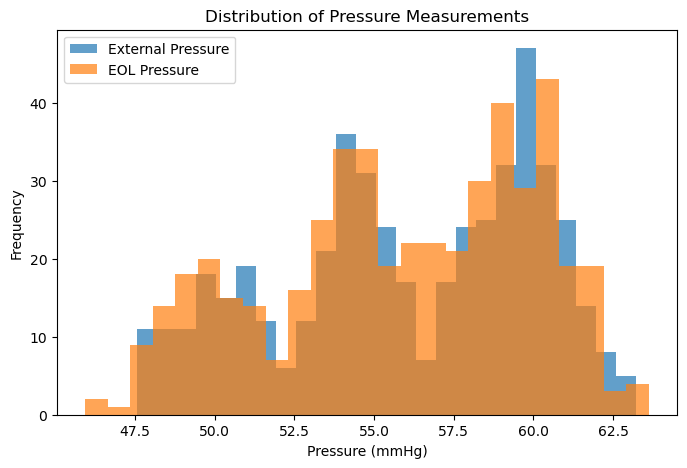

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df["ext_pressure_mmhg"], bins=25, alpha=0.7, label="External Pressure")
plt.hist(df["eol_pressure_mmhg"], bins=25, alpha=0.7, label="EOL Pressure")
plt.xlabel("Pressure (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of Pressure Measurements")
plt.legend()
plt.show()

## Pressure Distribution

The histogram provides an initial view of how the pressure measurements from the external setup and the EOL system are distributed. At this stage, the goal is to visually inspect whether the two sources appear broadly similar and whether one source shows greater spread or shift.

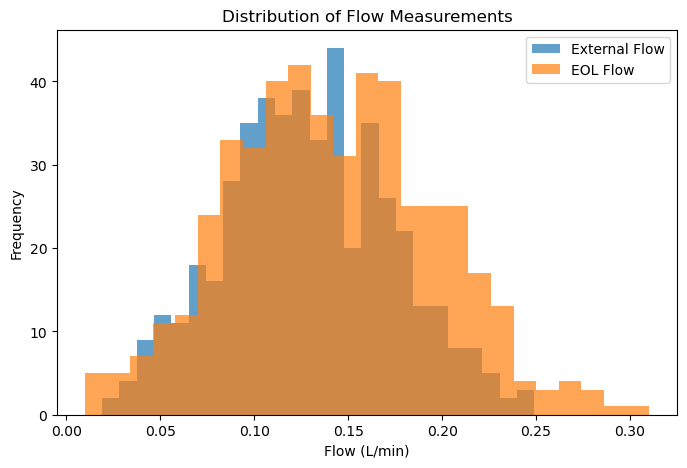

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(df["ext_flow_lmin"], bins=25, alpha=0.7, label="External Flow")
plt.hist(df["eol_flow_lmin"], bins=25, alpha=0.7, label="EOL Flow")
plt.xlabel("Flow (L/min)")
plt.ylabel("Frequency")
plt.title("Distribution of Flow Measurements")
plt.legend()
plt.show()

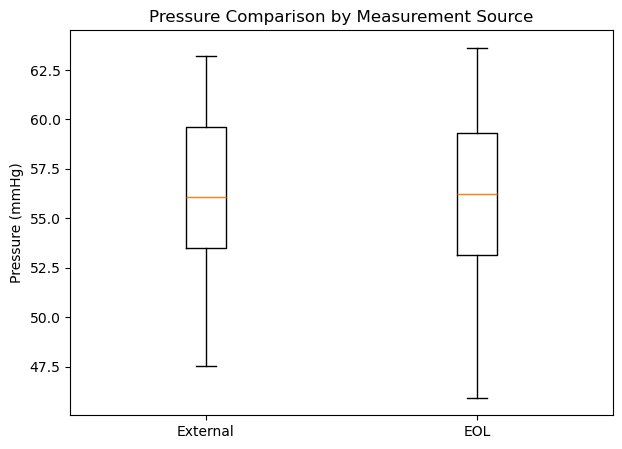

In [33]:
pressure_data = [df["ext_pressure_mmhg"], df["eol_pressure_mmhg"]]

plt.figure(figsize=(7, 5))
plt.boxplot(pressure_data, tick_labels=["External", "EOL"])
plt.ylabel("Pressure (mmHg)")
plt.title("Pressure Comparison by Measurement Source")
plt.show()

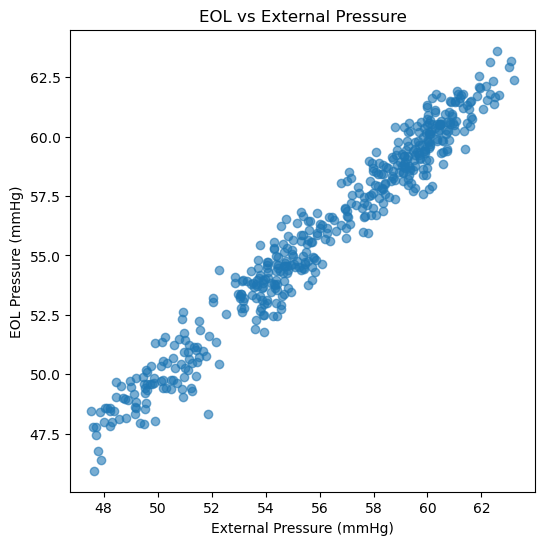

In [35]:
plt.figure(figsize=(6, 6))
plt.scatter(df["ext_pressure_mmhg"], df["eol_pressure_mmhg"], alpha=0.6)
plt.xlabel("External Pressure (mmHg)")
plt.ylabel("EOL Pressure (mmHg)")
plt.title("EOL vs External Pressure")
plt.show()

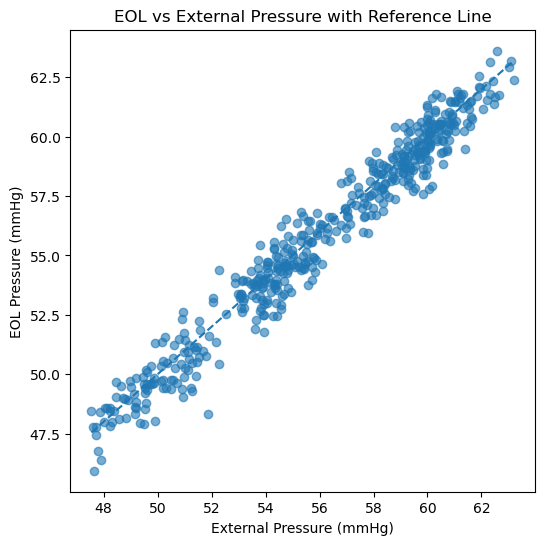

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(df["ext_pressure_mmhg"], df["eol_pressure_mmhg"], alpha=0.6)
plt.plot(
    [df["ext_pressure_mmhg"].min(), df["ext_pressure_mmhg"].max()],
    [df["ext_pressure_mmhg"].min(), df["ext_pressure_mmhg"].max()],
    linestyle="--"
)
plt.xlabel("External Pressure (mmHg)")
plt.ylabel("EOL Pressure (mmHg)")
plt.title("EOL vs External Pressure with Reference Line")
plt.show()

## Pressure Agreement Plot

The scatter plot compares paired pressure measurements from the external setup and the EOL system. Points close to the diagonal reference line indicate agreement between the two sources, while systematic deviation from the line may indicate bias or drift.

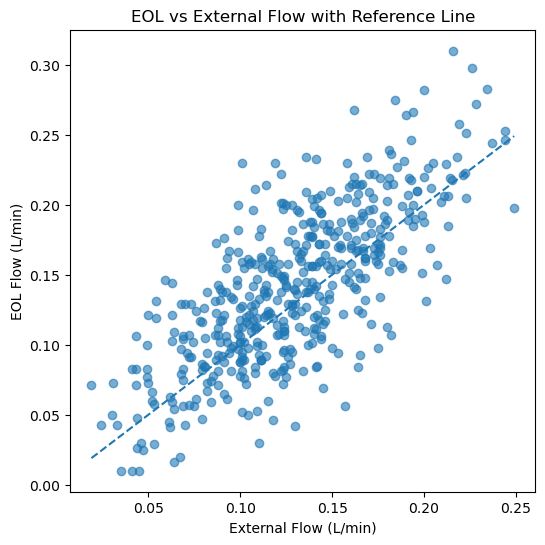

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(df["ext_flow_lmin"], df["eol_flow_lmin"], alpha=0.6)
plt.plot(
    [df["ext_flow_lmin"].min(), df["ext_flow_lmin"].max()],
    [df["ext_flow_lmin"].min(), df["ext_flow_lmin"].max()],
    linestyle="--"
)
plt.xlabel("External Flow (L/min)")
plt.ylabel("EOL Flow (L/min)")
plt.title("EOL vs External Flow with Reference Line")
plt.show()

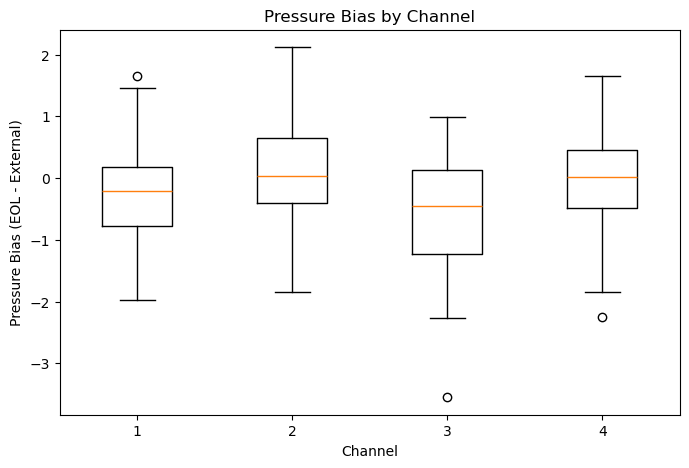

In [42]:
channel_groups = [df[df["channel"] == ch]["pressure_bias"] for ch in sorted(df["channel"].unique())]

plt.figure(figsize=(8, 5))
plt.boxplot(channel_groups, tick_labels=sorted(df["channel"].unique()))
plt.xlabel("Channel")
plt.ylabel("Pressure Bias (EOL - External)")
plt.title("Pressure Bias by Channel")
plt.show()

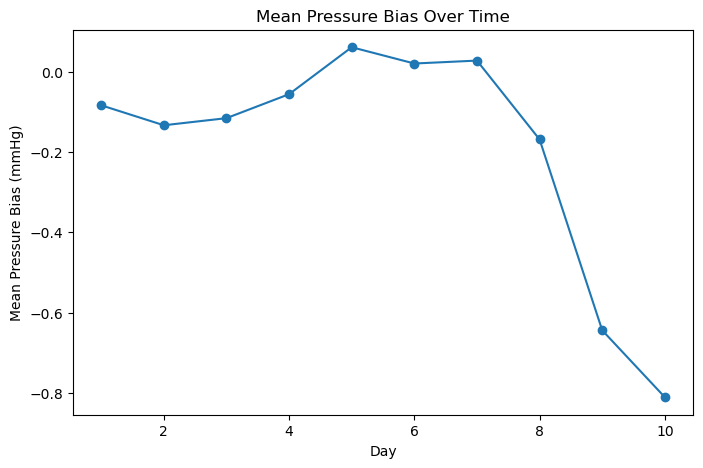

In [44]:
day_bias = df.groupby("day")["pressure_bias"].mean()

plt.figure(figsize=(8, 5))
plt.plot(day_bias.index, day_bias.values, marker="o")
plt.xlabel("Day")
plt.ylabel("Mean Pressure Bias (mmHg)")
plt.title("Mean Pressure Bias Over Time")
plt.show()

## Time Trend in Pressure Bias

The day-level trend in pressure bias provides an initial visual check for drift. A gradual movement toward more negative or more positive bias over time may indicate a changing relationship between the EOL system and the external reference setup.

In [47]:
pressure_corr = df["ext_pressure_mmhg"].corr(df["eol_pressure_mmhg"])
flow_corr = df["ext_flow_lmin"].corr(df["eol_flow_lmin"])

print("Pressure correlation:", round(pressure_corr, 3))
print("Flow correlation:", round(flow_corr, 3))

Pressure correlation: 0.98
Flow correlation: 0.738


## Initial EDA Interpretation

The first exploratory plots show that the EOL and external measurement systems are strongly related, especially for pressure, where the paired values are concentrated near the diagonal agreement line.

At the same time, the grouped visualizations indicate that the EOL system is not perfectly identical to the external reference. Channel-level pressure bias suggests channel-specific behavior, with some channels tending to measure slightly higher or lower than the reference.

The time-based pressure bias trend also indicates a gradual shift in the later study days, which is consistent with the intended synthetic drift introduced into the EOL system.

## Day 3 Progress Summary

On Day 3, the generated dataset was validated and explored using standard data-analysis checks and initial visualizations.

The main outcomes of this stage are:
- confirmation of dataset structure and variable consistency
- verification that no missing values or duplicate measurement records are present
- initial descriptive summaries of pressure, flow, and bias variables
- first visual confirmation of source differences, channel effects, and time-related behavior

These results provide the basis for more focused distribution analysis, probability density interpretation, and formal hypothesis testing in the next stages of the project.

## Day 4 Objective

The objective of Day 4 is to deepen the exploratory data analysis through more focused visualizations and grouped comparisons.

This stage emphasizes:
- pressure and flow bias distributions
- channel-level differences
- decision-based comparisons
- time-based trends
- interpretation of how measurement differences may influence practical testing outcomes

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("synthetic_eol_measurement_data.csv")

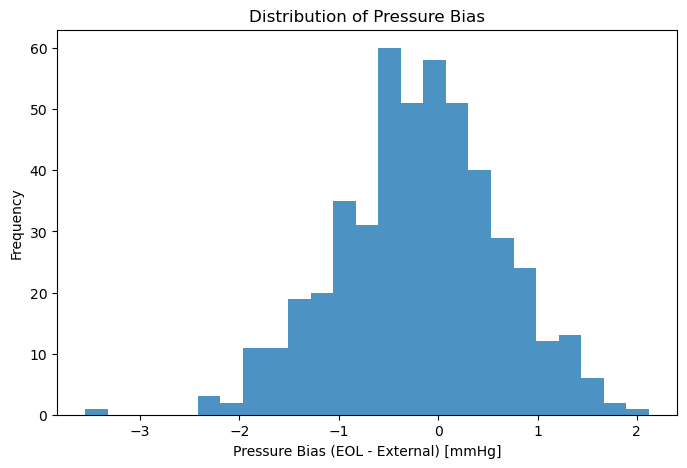

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df["pressure_bias"], bins=25, alpha=0.8)
plt.xlabel("Pressure Bias (EOL - External) [mmHg]")
plt.ylabel("Frequency")
plt.title("Distribution of Pressure Bias")
plt.show()

## Pressure Bias Distribution

The pressure bias distribution shows how far the EOL pressure measurements deviate from the external reference measurements. A distribution centered near zero suggests general agreement, while a shift away from zero indicates systematic bias.

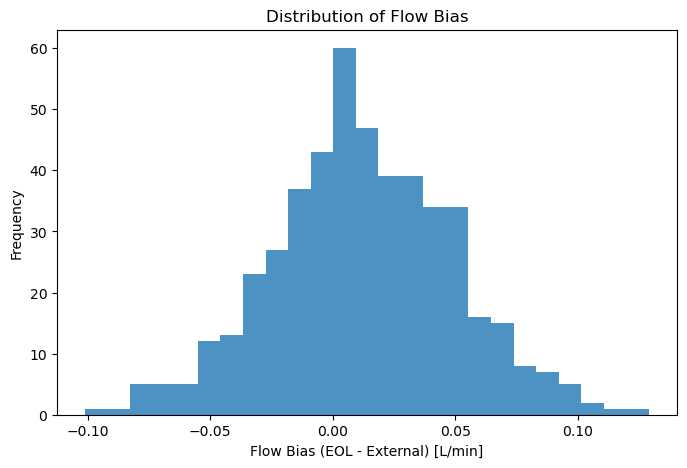

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["flow_bias"], bins=25, alpha=0.8)
plt.xlabel("Flow Bias (EOL - External) [L/min]")
plt.ylabel("Frequency")
plt.title("Distribution of Flow Bias")
plt.show()

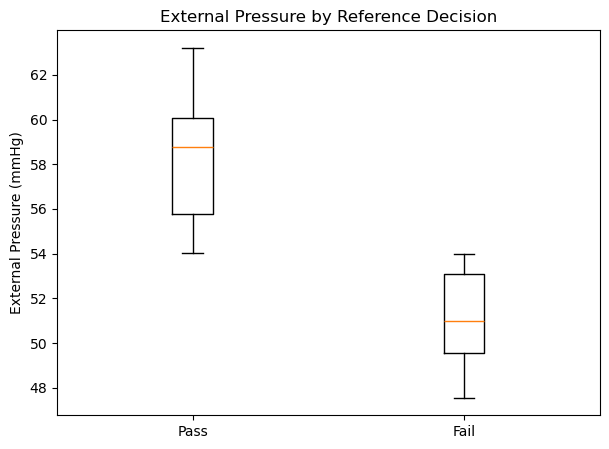

In [10]:
pass_fail_pressure = [
    df[df["reference_decision"] == "Pass"]["ext_pressure_mmhg"],
    df[df["reference_decision"] == "Fail"]["ext_pressure_mmhg"]
]

plt.figure(figsize=(7, 5))
plt.boxplot(pass_fail_pressure, tick_labels=["Pass", "Fail"])
plt.ylabel("External Pressure (mmHg)")
plt.title("External Pressure by Reference Decision")
plt.show()

## Pressure by Decision Outcome

This comparison shows whether Pass and Fail units are clearly separated in terms of measured pressure. A visible difference between the two groups supports the validity of the selected threshold-based decision rule.

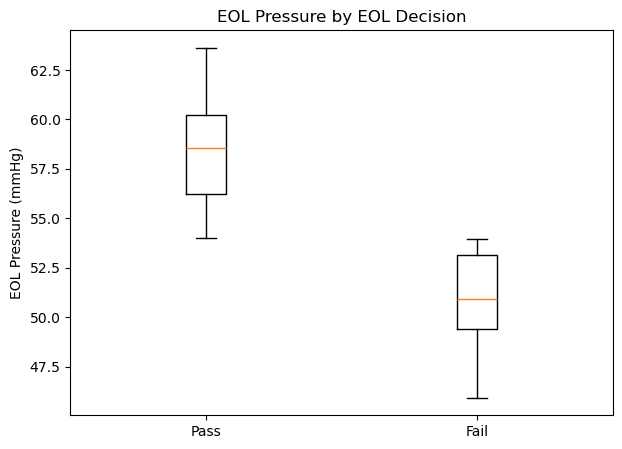

In [13]:
eol_decision_pressure = [
    df[df["eol_decision"] == "Pass"]["eol_pressure_mmhg"],
    df[df["eol_decision"] == "Fail"]["eol_pressure_mmhg"]
]

plt.figure(figsize=(7, 5))
plt.boxplot(eol_decision_pressure, tick_labels=["Pass", "Fail"])
plt.ylabel("EOL Pressure (mmHg)")
plt.title("EOL Pressure by EOL Decision")
plt.show()

In [15]:
df["decision_comparison"] = np.select(
    [
        (df["reference_decision"] == "Pass") & (df["eol_decision"] == "Pass"),
        (df["reference_decision"] == "Fail") & (df["eol_decision"] == "Fail"),
        (df["reference_decision"] == "Fail") & (df["eol_decision"] == "Pass"),
        (df["reference_decision"] == "Pass") & (df["eol_decision"] == "Fail")
    ],
    [
        "True Pass",
        "True Fail",
        "False Pass",
        "False Fail"
    ],
    default="Other"
)

df["decision_comparison"].value_counts()

decision_comparison
True Pass     311
True Fail     138
False Fail     22
False Pass      9
Name: count, dtype: int64

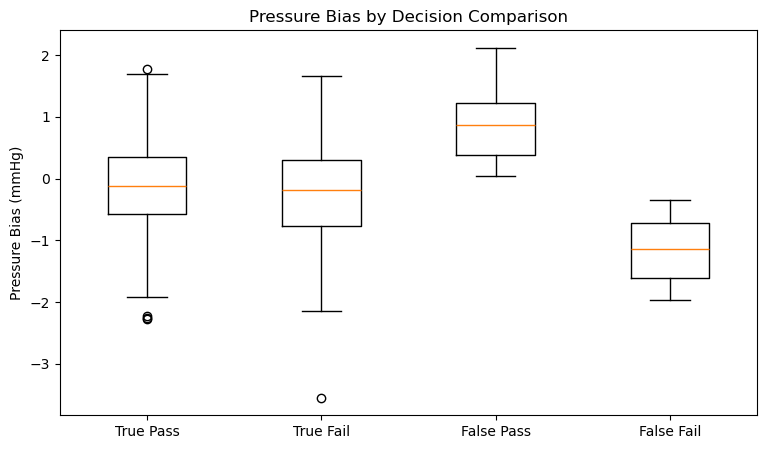

In [17]:
groups = [
    df[df["decision_comparison"] == "True Pass"]["pressure_bias"],
    df[df["decision_comparison"] == "True Fail"]["pressure_bias"],
    df[df["decision_comparison"] == "False Pass"]["pressure_bias"],
    df[df["decision_comparison"] == "False Fail"]["pressure_bias"]
]

plt.figure(figsize=(9, 5))
plt.boxplot(groups, tick_labels=["True Pass", "True Fail", "False Pass", "False Fail"])
plt.ylabel("Pressure Bias (mmHg)")
plt.title("Pressure Bias by Decision Comparison")
plt.show()

## Pressure Bias and Decision Mismatch

This plot helps connect measurement bias with practical decision outcomes. If false pass or false fail groups are associated with stronger bias, this suggests that small measurement differences near the threshold may influence product classification.

The grouped bias plot shows a strong relationship between pressure bias and decision mismatch outcomes. False pass cases are associated with positive pressure bias, meaning the EOL system tends to read higher than the external reference. False fail cases are associated with negative pressure bias, meaning the EOL system tends to read lower than the reference. This confirms that relatively small deviations near the threshold can influence the final Pass/Fail classification.

In short it shows a very clear practical pattern:

False Pass cases have strongly positive pressure bias
False Fail cases have strongly negative pressure bias
True Pass and True Fail are closer to zero overall

This is extremely useful, because it directly links measurement bias to decision error.

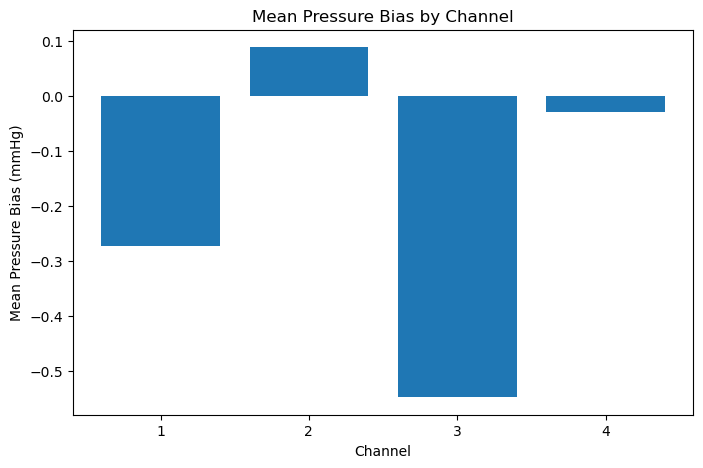

In [20]:
channel_pressure_bias_mean = df.groupby("channel")["pressure_bias"].mean()

plt.figure(figsize=(8, 5))
plt.bar(channel_pressure_bias_mean.index.astype(str), channel_pressure_bias_mean.values)
plt.xlabel("Channel")
plt.ylabel("Mean Pressure Bias (mmHg)")
plt.title("Mean Pressure Bias by Channel")
plt.show()

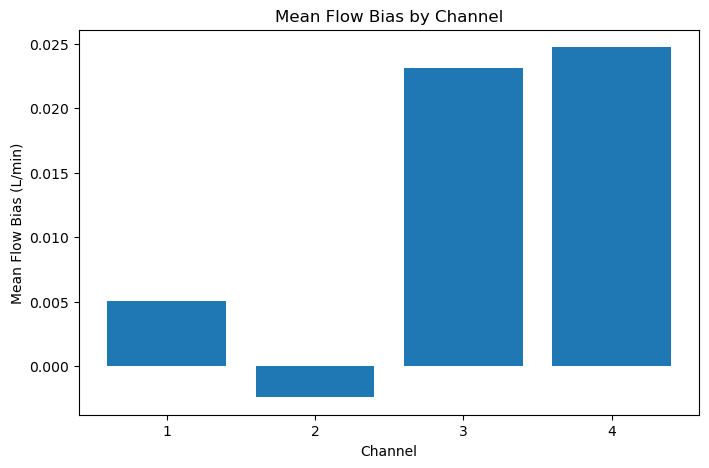

In [22]:
channel_flow_bias_mean = df.groupby("channel")["flow_bias"].mean()

plt.figure(figsize=(8, 5))
plt.bar(channel_flow_bias_mean.index.astype(str), channel_flow_bias_mean.values)
plt.xlabel("Channel")
plt.ylabel("Mean Flow Bias (L/min)")
plt.title("Mean Flow Bias by Channel")
plt.show()

## Channel-Level Bias

The channel-level mean bias plots provide a simplified view of how the EOL system behaves across channels. Differences between channels may indicate systematic channel effects rather than purely random variation.

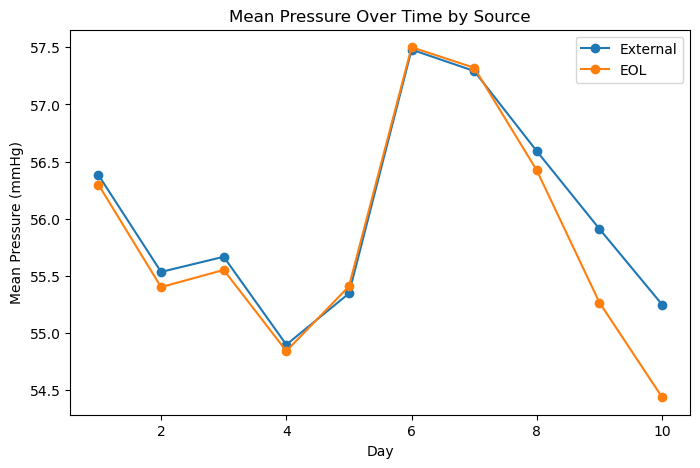

In [25]:
pressure_by_day = df.groupby("day")[["ext_pressure_mmhg", "eol_pressure_mmhg"]].mean()

plt.figure(figsize=(8, 5))
plt.plot(pressure_by_day.index, pressure_by_day["ext_pressure_mmhg"], marker="o", label="External")
plt.plot(pressure_by_day.index, pressure_by_day["eol_pressure_mmhg"], marker="o", label="EOL")
plt.xlabel("Day")
plt.ylabel("Mean Pressure (mmHg)")
plt.title("Mean Pressure Over Time by Source")
plt.legend()
plt.show()

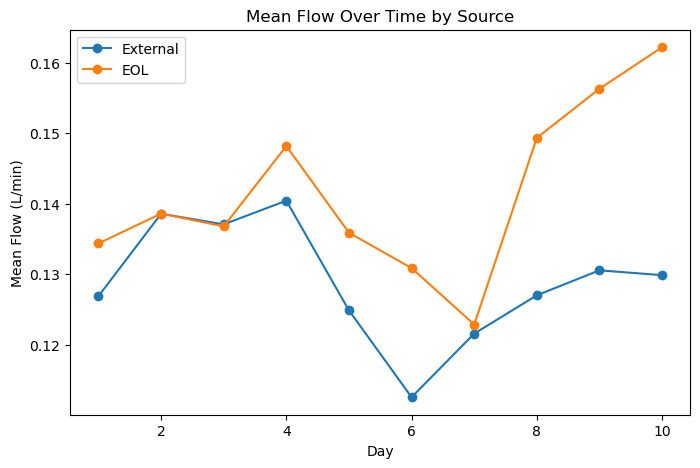

In [27]:
flow_by_day = df.groupby("day")[["ext_flow_lmin", "eol_flow_lmin"]].mean()

plt.figure(figsize=(8, 5))
plt.plot(flow_by_day.index, flow_by_day["ext_flow_lmin"], marker="o", label="External")
plt.plot(flow_by_day.index, flow_by_day["eol_flow_lmin"], marker="o", label="EOL")
plt.xlabel("Day")
plt.ylabel("Mean Flow (L/min)")
plt.title("Mean Flow Over Time by Source")
plt.legend()
plt.show()

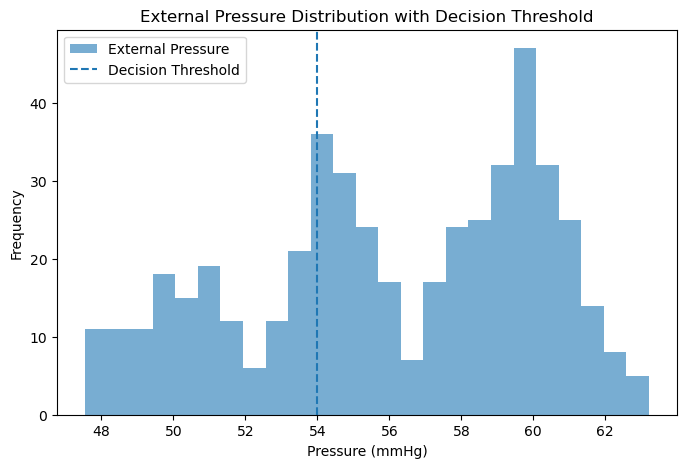

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(df["ext_pressure_mmhg"], bins=25, alpha=0.6, label="External Pressure")
plt.axvline(54.0, linestyle="--", label="Decision Threshold")
plt.xlabel("Pressure (mmHg)")
plt.ylabel("Frequency")
plt.title("External Pressure Distribution with Decision Threshold")
plt.legend()
plt.show()

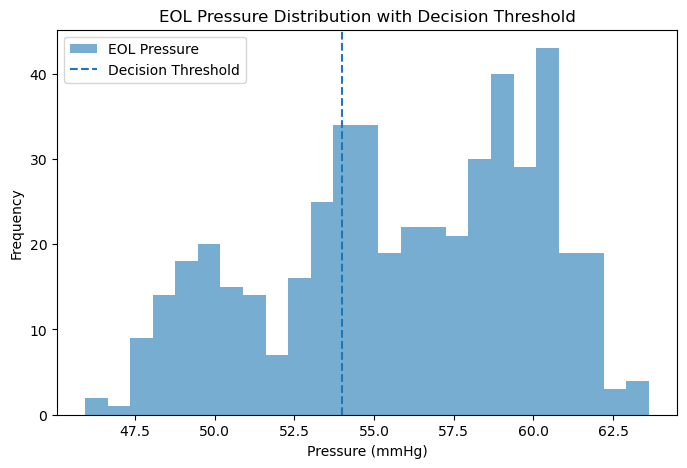

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(df["eol_pressure_mmhg"], bins=25, alpha=0.6, label="EOL Pressure")
plt.axvline(54.0, linestyle="--", label="Decision Threshold")
plt.xlabel("Pressure (mmHg)")
plt.ylabel("Frequency")
plt.title("EOL Pressure Distribution with Decision Threshold")
plt.legend()
plt.show()

## Threshold-Oriented View

The threshold-oriented distributions help visualize how many units are located near the decision boundary. Observations close to the threshold are especially important because they are the most likely to generate false pass or false fail outcomes when measurement variation is present.

In [34]:
borderline_df = df[(df["ext_pressure_mmhg"] >= 53) & (df["ext_pressure_mmhg"] <= 55)]
print("Borderline observations:", len(borderline_df))
borderline_df[[
    "sample_id",
    "day",
    "channel",
    "ext_pressure_mmhg",
    "eol_pressure_mmhg",
    "pressure_bias",
    "reference_decision",
    "eol_decision"
]].head(10)

Borderline observations: 94


,sample_id,day,channel,ext_pressure_mmhg,eol_pressure_mmhg,pressure_bias,reference_decision,eol_decision
2,S003,1,1,54.04,53.00,-1.04,Pass,Fail
11,S012,1,1,53.32,53.92,0.60,Fail,Fail
14,S015,1,2,53.86,53.14,-0.72,Fail,Fail
15,S016,1,2,54.37,54.33,-0.04,Pass,Pass
17,S018,1,2,53.16,53.96,0.80,Fail,Fail
22,S023,1,2,53.89,53.85,-0.04,Fail,Fail
24,S025,1,3,53.19,52.78,-0.41,Fail,Fail
26,S027,1,3,54.37,53.02,-1.35,Pass,Fail
28,S029,1,3,53.93,52.48,-1.45,Fail,Fail
47,S048,1,4,53.10,52.79,-0.31,Fail,Fail


## Borderline Observations

Borderline observations are units whose measured pressure lies close to the acceptance threshold. These observations are especially informative because small shifts in bias or additional noise can change the final Pass/Fail decision.

In [37]:
df["decision_comparison"].value_counts()

decision_comparison
True Pass     311
True Fail     138
False Fail     22
False Pass      9
Name: count, dtype: int64

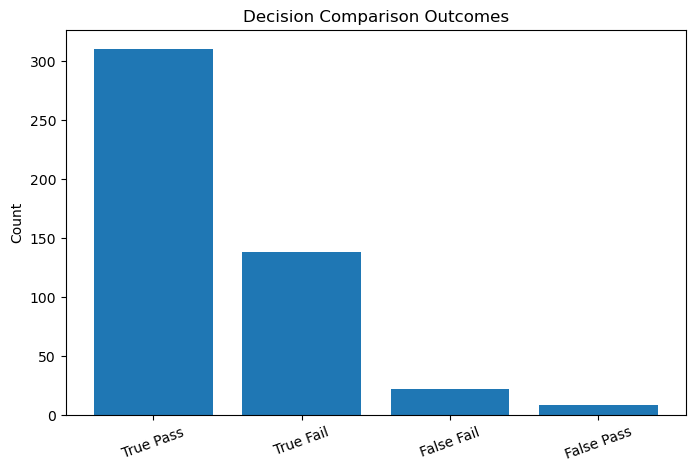

In [39]:
decision_counts = df["decision_comparison"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(decision_counts.index, decision_counts.values)
plt.ylabel("Count")
plt.title("Decision Comparison Outcomes")
plt.xticks(rotation=20)
plt.show()

## Day 4 Interpretation

The deeper exploratory analysis reinforces the main structure of the synthetic dataset. The pressure bias distribution is centered near zero but slightly negative overall, which is consistent with the intended behavior of the EOL system.

The decision-oriented bias comparison is especially informative. False pass outcomes are linked to positive pressure bias, while false fail outcomes are linked to negative pressure bias. This shows that measurement bias is not only a statistical quantity, but also a practically important factor in threshold-based product classification.

The time-based mean pressure plots show that the EOL system begins to separate more clearly from the external reference during the later study days, which supports the intended mild drift scenario. In addition, the presence of 94 borderline observations confirms that the dataset contains enough threshold-adjacent cases for a meaningful decision-risk and PDF-based analysis in the next stages.

## Day 5 Objective

The objective of Day 5 is to analyze the measurement distributions from a probability density perspective.

This stage focuses on:
- understanding the probability density function (PDF) concept
- comparing the distribution shapes of the EOL and external measurements
- studying overlap between the two sources
- examining the region near the decision threshold
- connecting distribution overlap to false pass / false fail risk

## Probability Density Function (PDF)

A probability density function (PDF) describes how the values of a continuous variable are distributed. Instead of showing only counts in bins, as in a histogram, the PDF provides a smoother representation of where values are more or less likely to occur.

In this project, the PDF perspective is useful because it helps compare the measurement behavior of the EOL system and the external reference setup. It is especially important near the decision threshold, where even small shifts in density may influence Pass/Fail outcomes.

A high density near the threshold means that many observations are close to the acceptance boundary. In such a case, even small bias or additional variation may increase the probability of false pass or false fail decisions.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("synthetic_eol_measurement_data.csv")
threshold_pressure = 54.0

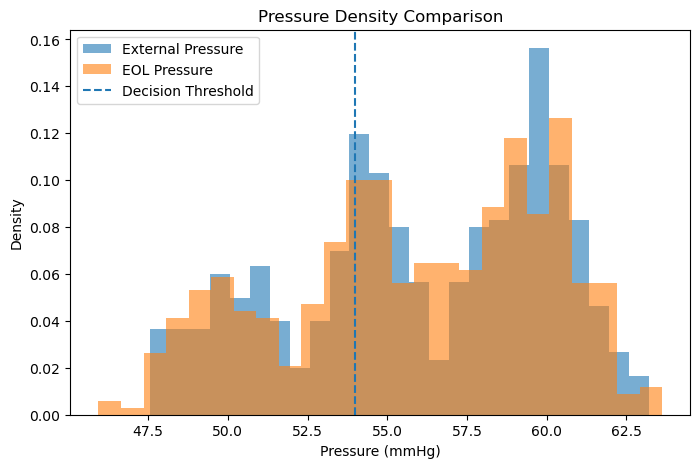

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["ext_pressure_mmhg"], bins=25, density=True, alpha=0.6, label="External Pressure")
plt.hist(df["eol_pressure_mmhg"], bins=25, density=True, alpha=0.6, label="EOL Pressure")
plt.axvline(threshold_pressure, linestyle="--", label="Decision Threshold")
plt.xlabel("Pressure (mmHg)")
plt.ylabel("Density")
plt.title("Pressure Density Comparison")
plt.legend()
plt.show()

## Pressure Density Comparison

The density-based histogram shows how the pressure values are distributed for both measurement sources. Strong overlap suggests general agreement, while local shifts in density indicate regions where one source may systematically differ from the other.

The region near the threshold is especially important, because density concentration there may contribute to classification instability.

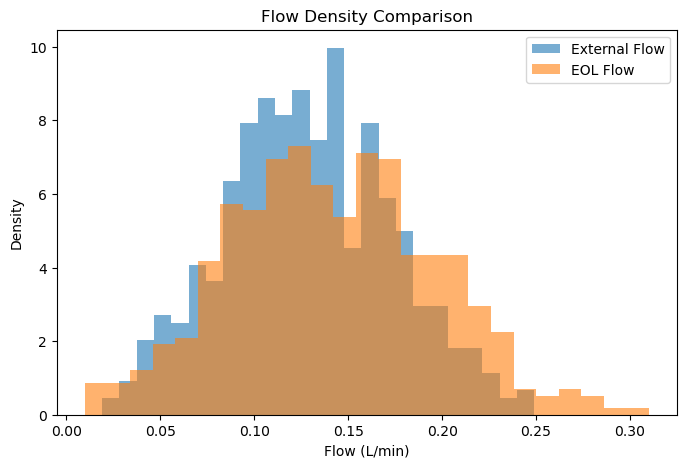

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["ext_flow_lmin"], bins=25, density=True, alpha=0.6, label="External Flow")
plt.hist(df["eol_flow_lmin"], bins=25, density=True, alpha=0.6, label="EOL Flow")
plt.xlabel("Flow (L/min)")
plt.ylabel("Density")
plt.title("Flow Density Comparison")
plt.legend()
plt.show()

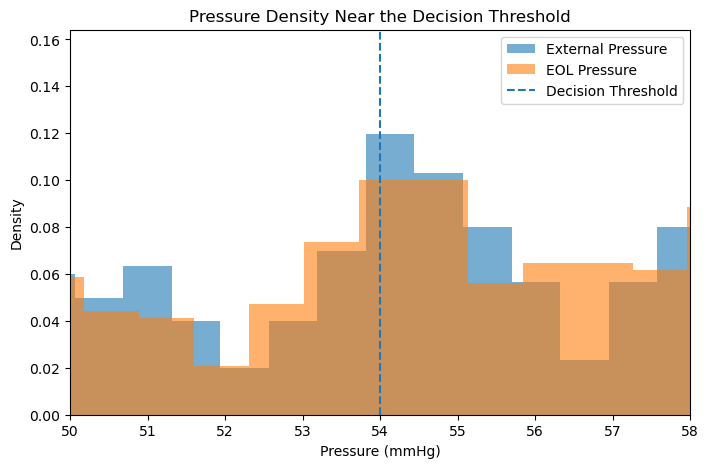

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["ext_pressure_mmhg"], bins=25, density=True, alpha=0.6, label="External Pressure")
plt.hist(df["eol_pressure_mmhg"], bins=25, density=True, alpha=0.6, label="EOL Pressure")
plt.axvline(threshold_pressure, linestyle="--", label="Decision Threshold")
plt.xlim(50, 58)
plt.xlabel("Pressure (mmHg)")
plt.ylabel("Density")
plt.title("Pressure Density Near the Decision Threshold")
plt.legend()
plt.show()

## Density Near the Threshold

This zoomed view focuses on the region around the decision threshold. It helps reveal whether the two sources have similar or different density mass near the acceptance boundary.

If one source places more density slightly above or below the threshold, this may help explain false pass or false fail outcomes.

In [15]:
near_threshold_df = df[(df["ext_pressure_mmhg"] >= 53.0) & (df["ext_pressure_mmhg"] <= 55.0)]

print("Observations near threshold:", len(near_threshold_df))
print("False pass near threshold:", near_threshold_df["false_pass"].sum())
print("False fail near threshold:", near_threshold_df["false_fail"].sum())

Observations near threshold: 94
False pass near threshold: 7
False fail near threshold: 20


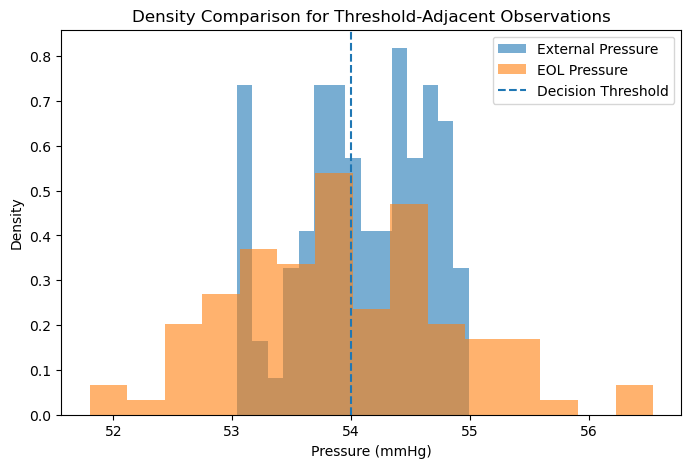

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(near_threshold_df["ext_pressure_mmhg"], bins=15, density=True, alpha=0.6, label="External Pressure")
plt.hist(near_threshold_df["eol_pressure_mmhg"], bins=15, density=True, alpha=0.6, label="EOL Pressure")
plt.axvline(threshold_pressure, linestyle="--", label="Decision Threshold")
plt.xlabel("Pressure (mmHg)")
plt.ylabel("Density")
plt.title("Density Comparison for Threshold-Adjacent Observations")
plt.legend()
plt.show()

In [19]:
ext_near_threshold_prob = ((df["ext_pressure_mmhg"] >= 53.0) & (df["ext_pressure_mmhg"] <= 55.0)).mean()
eol_near_threshold_prob = ((df["eol_pressure_mmhg"] >= 53.0) & (df["eol_pressure_mmhg"] <= 55.0)).mean()

print("Approximate probability of being near threshold (External):", round(ext_near_threshold_prob, 3))
print("Approximate probability of being near threshold (EOL):", round(eol_near_threshold_prob, 3))

Approximate probability of being near threshold (External): 0.196
Approximate probability of being near threshold (EOL): 0.194


In [21]:
ext_below = (df["ext_pressure_mmhg"] < threshold_pressure).mean()
ext_above = (df["ext_pressure_mmhg"] >= threshold_pressure).mean()

eol_below = (df["eol_pressure_mmhg"] < threshold_pressure).mean()
eol_above = (df["eol_pressure_mmhg"] >= threshold_pressure).mean()

print("External below threshold:", round(ext_below, 3))
print("External at/above threshold:", round(ext_above, 3))
print("EOL below threshold:", round(eol_below, 3))
print("EOL at/above threshold:", round(eol_above, 3))

External below threshold: 0.306
External at/above threshold: 0.694
EOL below threshold: 0.333
EOL at/above threshold: 0.667


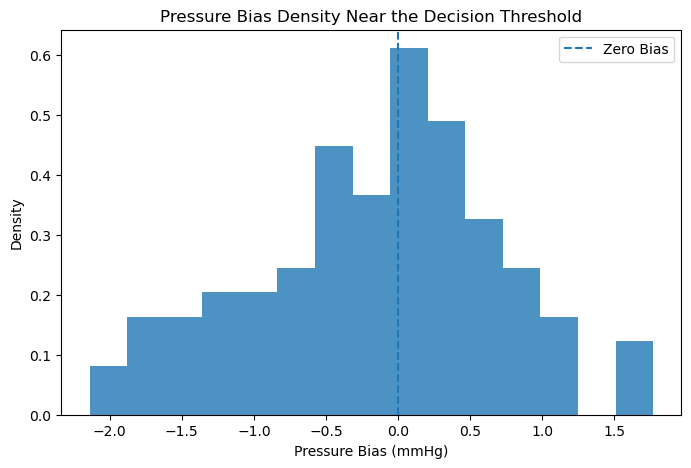

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(near_threshold_df["pressure_bias"], bins=15, density=True, alpha=0.8)
plt.axvline(0, linestyle="--", label="Zero Bias")
plt.xlabel("Pressure Bias (mmHg)")
plt.ylabel("Density")
plt.title("Pressure Bias Density Near the Decision Threshold")
plt.legend()
plt.show()

## Bias Density Near the Threshold

This plot focuses on the pressure bias distribution specifically for threshold-adjacent observations. This is one of the most practically important regions in the dataset, because small positive or negative bias in this area may directly affect the final classification result.

In [26]:
pdf_summary = pd.DataFrame({
    "Metric": [
        "External near-threshold probability",
        "EOL near-threshold probability",
        "External below-threshold probability",
        "EOL below-threshold probability",
        "False pass rate",
        "False fail rate"
    ],
    "Value": [
        ext_near_threshold_prob,
        eol_near_threshold_prob,
        ext_below,
        eol_below,
        df["false_pass"].mean(),
        df["false_fail"].mean()
    ]
})

pdf_summary["Value"] = pdf_summary["Value"].round(3)
pdf_summary

,Metric,Value
0,External near-threshold probability,0.196
1,EOL near-threshold probability,0.194
2,External below-threshold probability,0.306
3,EOL below-threshold probability,0.333
4,False pass rate,0.019
5,False fail rate,0.046


## PDF-Based Interpretation

The probability density perspective shows that the EOL and external measurement systems are broadly similar in their overall pressure distribution, but not perfectly identical.

The most important difference appears near the decision threshold. In that region, even modest shifts in density or bias can influence whether an observation falls above or below the acceptance limit. This helps explain why false pass and false fail cases occur even when the two systems remain strongly correlated overall.

From a practical engineering perspective, the threshold-adjacent region is the most decision-sensitive part of the measurement space. Therefore, density overlap near the threshold is more important than similarity in the far tails of the distribution.

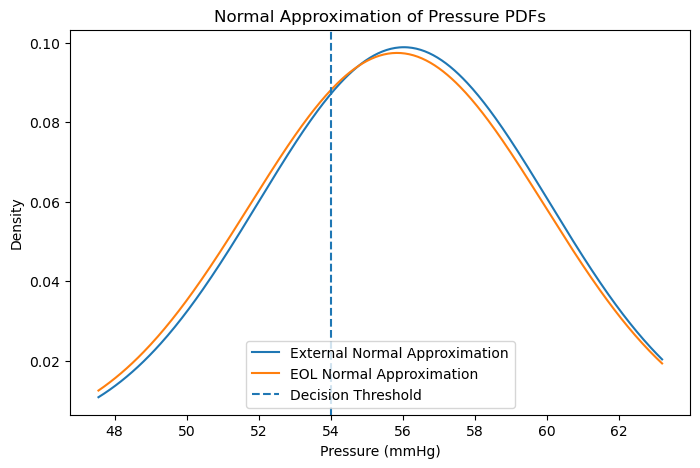

In [29]:
x = np.linspace(df["ext_pressure_mmhg"].min(), df["ext_pressure_mmhg"].max(), 400)

ext_mean = df["ext_pressure_mmhg"].mean()
ext_std = df["ext_pressure_mmhg"].std()

eol_mean = df["eol_pressure_mmhg"].mean()
eol_std = df["eol_pressure_mmhg"].std()

ext_pdf = (1 / (ext_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - ext_mean) / ext_std) ** 2)
eol_pdf = (1 / (eol_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - eol_mean) / eol_std) ** 2)

plt.figure(figsize=(8, 5))
plt.plot(x, ext_pdf, label="External Normal Approximation")
plt.plot(x, eol_pdf, label="EOL Normal Approximation")
plt.axvline(threshold_pressure, linestyle="--", label="Decision Threshold")
plt.xlabel("Pressure (mmHg)")
plt.ylabel("Density")
plt.title("Normal Approximation of Pressure PDFs")
plt.legend()
plt.show()

## Normal Approximation Note

The normal-style PDF curves shown above are only approximations based on the sample means and standard deviations. They are useful for visual comparison, but the histogram-based density view remains closer to the actual synthetic dataset structure.

The PDF-based analysis confirms that the EOL and external systems are broadly similar in their overall pressure behavior, but not perfectly identical.

The near-threshold probabilities are very close for the two sources, which means that both systems place a substantial portion of observations in the decision-sensitive region. At the same time, the EOL system has a higher below-threshold probability, which is consistent with the higher false fail rate observed in the dataset.

This shows that even when two systems are strongly correlated and have similar overall distributions, small shifts in density near the threshold can still produce practically important decision differences.

## Day 5 Progress Summary

On Day 5, the analysis moved from general exploratory visualization to a probability density perspective.

The main outcomes of this stage are:
- a clearer explanation of the PDF concept in the context of measurement systems
- density-based comparison of pressure and flow measurements from both sources
- focused analysis of the threshold-adjacent region
- approximate probability estimates for observations near the acceptance boundary
- a stronger connection between density overlap, measurement bias, and false pass / false fail risk

This stage strengthens the mathematical foundation of the project and prepares the way for formal hypothesis testing and ANOVA analysis.

## Day 6 Objective

The objective of Day 6 is to formally evaluate whether the measurement differences observed between the EOL system and the external reference setup are statistically significant.

This stage focuses on:
- defining null and alternative hypotheses
- preparing the data for formal comparison
- applying analysis of variance (ANOVA)
- interpreting the results in both statistical and practical terms
- connecting the statistical findings to engineering decision-making

## Hypothesis Testing

Hypothesis testing is used to evaluate whether the observed differences in measured values are likely to reflect a real effect rather than random variation alone.

In this project, the main goal is to determine whether differences between the EOL system and the external reference setup are statistically significant. This is important because even relatively small differences may become practically important when measurements are used for Pass/Fail decisions near a threshold.

A small p-value suggests that the observed difference is unlikely to be explained only by random noise under the null hypothesis. However, statistical significance does not automatically imply practical significance, so both aspects must be interpreted separately.

## Analysis of Variance (ANOVA)

Analysis of Variance (ANOVA) is a statistical method used to compare group means and determine whether at least one group differs significantly from the others.

In this project, ANOVA is used to evaluate whether measured pressure values differ across:
- measurement source
- channel
- time (day)

This is useful because the project is not limited to a single pairwise comparison. Instead, the analysis needs to consider structured sources of variation in the synthetic measurement system.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.read_csv("synthetic_eol_measurement_data.csv")
threshold_pressure = 54.0

## Main Hypotheses

The main statistical hypotheses for the source comparison are:

**Null hypothesis (H0):**  
There is no statistically significant difference in mean pressure between the EOL system and the external reference setup.

**Alternative hypothesis (H1):**  
There is a statistically significant difference in mean pressure between the EOL system and the external reference setup.

In [7]:
t_stat_pressure, p_value_pressure = stats.ttest_rel(df["eol_pressure_mmhg"], df["ext_pressure_mmhg"])

print("Paired t-test for pressure")
print("t-statistic:", round(t_stat_pressure, 4))
print("p-value:", round(p_value_pressure, 6))

Paired t-test for pressure
t-statistic: -5.1243
p-value: 0.0


## Paired Pressure Comparison

The paired t-test evaluates whether the mean pressure difference between the EOL system and the external reference setup is significantly different from zero.

Because the measurements are paired by sample, this test provides a direct first check of source-related mean difference before moving to the broader ANOVA framework.

In [10]:
t_stat_flow, p_value_flow = stats.ttest_rel(df["eol_flow_lmin"], df["ext_flow_lmin"])

print("Paired t-test for flow")
print("t-statistic:", round(t_stat_flow, 4))
print("p-value:", round(p_value_flow, 6))

Paired t-test for flow
t-statistic: 7.434
p-value: 0.0


In [12]:
pressure_long = pd.DataFrame({
    "sample_id": np.concatenate([df["sample_id"], df["sample_id"]]),
    "day": np.concatenate([df["day"], df["day"]]),
    "channel": np.concatenate([df["channel"], df["channel"]]),
    "source": ["External"] * len(df) + ["EOL"] * len(df),
    "pressure_mmhg": np.concatenate([df["ext_pressure_mmhg"], df["eol_pressure_mmhg"]])
})

pressure_long.head()

,sample_id,day,channel,source,pressure_mmhg
0,S001,1,1,External,63.21
1,S002,1,1,External,51.34
2,S003,1,1,External,54.04
3,S004,1,1,External,59.93
4,S005,1,1,External,61.08


In [14]:
pressure_long.groupby("source")["pressure_mmhg"].mean().round(3)

source
EOL         55.845
External    56.035
Name: pressure_mmhg, dtype: float64

In [16]:
pressure_long.groupby(["source", "channel"])["pressure_mmhg"].mean().round(3)

source    channel
EOL       1          55.807
          2          56.243
          3          55.673
          4          55.659
External  1          56.079
          2          56.154
          3          56.221
          4          55.687
Name: pressure_mmhg, dtype: float64

In [18]:
groups_by_source = [
    pressure_long[pressure_long["source"] == "External"]["pressure_mmhg"],
    pressure_long[pressure_long["source"] == "EOL"]["pressure_mmhg"]
]

f_stat_source, p_value_source = stats.f_oneway(*groups_by_source)

print("One-way ANOVA by source")
print("F-statistic:", round(f_stat_source, 4))
print("p-value:", round(p_value_source, 6))

One-way ANOVA by source
F-statistic: 0.5237
p-value: 0.469453


In [20]:
groups_by_channel = [
    df[df["channel"] == ch]["eol_pressure_mmhg"] for ch in sorted(df["channel"].unique())
]

f_stat_channel, p_value_channel = stats.f_oneway(*groups_by_channel)

print("One-way ANOVA for EOL pressure by channel")
print("F-statistic:", round(f_stat_channel, 4))
print("p-value:", round(p_value_channel, 6))

One-way ANOVA for EOL pressure by channel
F-statistic: 0.5325
p-value: 0.660176


## Channel Effect Test

The one-way ANOVA by channel evaluates whether the EOL pressure measurements differ significantly across the four channels. This is important because channel-specific behavior was intentionally introduced into the synthetic dataset and should now be tested formally.

In [23]:
groups_by_day = [
    df[df["day"] == d]["eol_pressure_mmhg"] for d in sorted(df["day"].unique())
]

f_stat_day, p_value_day = stats.f_oneway(*groups_by_day)

print("One-way ANOVA for EOL pressure by day")
print("F-statistic:", round(f_stat_day, 4))
print("p-value:", round(p_value_day, 6))

One-way ANOVA for EOL pressure by day
F-statistic: 3.0564
p-value: 0.001436


In [25]:
model_source_channel = ols("pressure_mmhg ~ C(source) + C(channel) + C(source):C(channel)", data=pressure_long).fit()
anova_source_channel = sm.stats.anova_lm(model_source_channel, typ=2)

anova_source_channel

,sum_sq,df,F,PR(>F)
C(source),8.656402,1.0,0.521964,0.470183
C(channel),33.140441,3.0,0.666101,0.572976
C(source):C(channel),14.335835,3.0,0.288141,0.833989
Residual,15788.243028,952.0,NaN,NaN


## Two-Way ANOVA: Source and Channel

The two-way ANOVA model evaluates whether pressure measurements differ according to:
- measurement source
- channel
- the interaction between source and channel

The interaction term is especially relevant because it tests whether the difference between the EOL and external systems changes from one channel to another.

In [28]:
model_source_day = ols("pressure_mmhg ~ C(source) + C(day) + C(source):C(day)", data=pressure_long).fit()
anova_source_day = sm.stats.anova_lm(model_source_day, typ=2)

anova_source_day

,sum_sq,df,F,PR(>F)
C(source),8.656402,1.0,0.540270,4.625040e-01
C(day),755.835927,9.0,5.241538,5.531318e-07
C(source):C(day),18.872661,9.0,0.130877,9.988924e-01
Residual,15061.010717,940.0,NaN,NaN


## Two-Way ANOVA: Source and Day

This ANOVA model evaluates whether pressure measurements differ according to:
- measurement source
- day
- the interaction between source and day

The source-by-day interaction is particularly important because it helps test whether the relationship between the EOL system and the external reference changes over time.

In [31]:
mean_ext_pressure = df["ext_pressure_mmhg"].mean()
mean_eol_pressure = df["eol_pressure_mmhg"].mean()
mean_difference_pressure = mean_eol_pressure - mean_ext_pressure

mean_ext_flow = df["ext_flow_lmin"].mean()
mean_eol_flow = df["eol_flow_lmin"].mean()
mean_difference_flow = mean_eol_flow - mean_ext_flow

print("Mean external pressure:", round(mean_ext_pressure, 3))
print("Mean EOL pressure:", round(mean_eol_pressure, 3))
print("Mean pressure difference (EOL - External):", round(mean_difference_pressure, 3))
print()
print("Mean external flow:", round(mean_ext_flow, 3))
print("Mean EOL flow:", round(mean_eol_flow, 3))
print("Mean flow difference (EOL - External):", round(mean_difference_flow, 3))

Mean external pressure: 56.035
Mean EOL pressure: 55.845
Mean pressure difference (EOL - External): -0.19

Mean external flow: 0.129
Mean EOL flow: 0.142
Mean flow difference (EOL - External): 0.013


In [33]:
significance_summary = pd.DataFrame({
    "Test": [
        "Paired t-test: Pressure",
        "Paired t-test: Flow",
        "One-way ANOVA: Source",
        "One-way ANOVA: Channel",
        "One-way ANOVA: Day"
    ],
    "p_value": [
        p_value_pressure,
        p_value_flow,
        p_value_source,
        p_value_channel,
        p_value_day
    ]
})

significance_summary["p_value"] = significance_summary["p_value"].round(6)
significance_summary["significant_at_0_05"] = significance_summary["p_value"] < 0.05

significance_summary

,Test,p_value,significant_at_0_05
0,Paired t-test: Pressure,0.000000,True
1,Paired t-test: Flow,0.000000,True
2,One-way ANOVA: Source,0.469453,False
3,One-way ANOVA: Channel,0.660176,False
4,One-way ANOVA: Day,0.001436,True


## Statistical Significance and Practical Meaning

The hypothesis tests and ANOVA results help determine whether the observed measurement differences are statistically significant. However, a statistically significant result does not automatically imply a large or practically important effect.

For this reason, the interpretation in this project considers both:
- the p-values from the formal statistical tests
- the actual magnitude and decision relevance of the observed differences

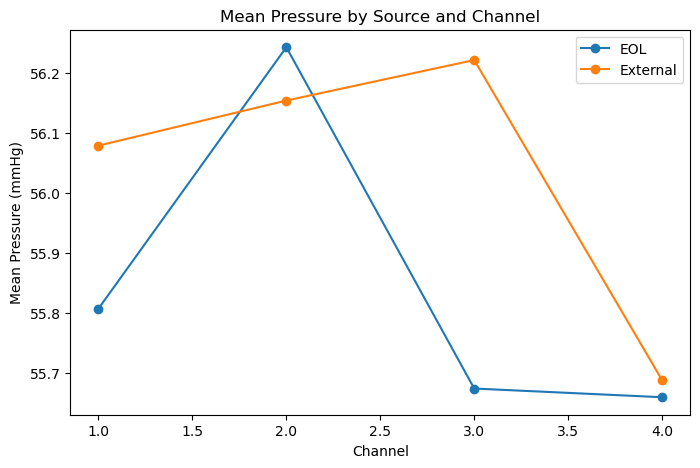

In [36]:
source_channel_means = pressure_long.groupby(["channel", "source"])["pressure_mmhg"].mean().unstack()

plt.figure(figsize=(8, 5))
for source in source_channel_means.columns:
    plt.plot(source_channel_means.index, source_channel_means[source], marker="o", label=source)

plt.xlabel("Channel")
plt.ylabel("Mean Pressure (mmHg)")
plt.title("Mean Pressure by Source and Channel")
plt.legend()
plt.show()

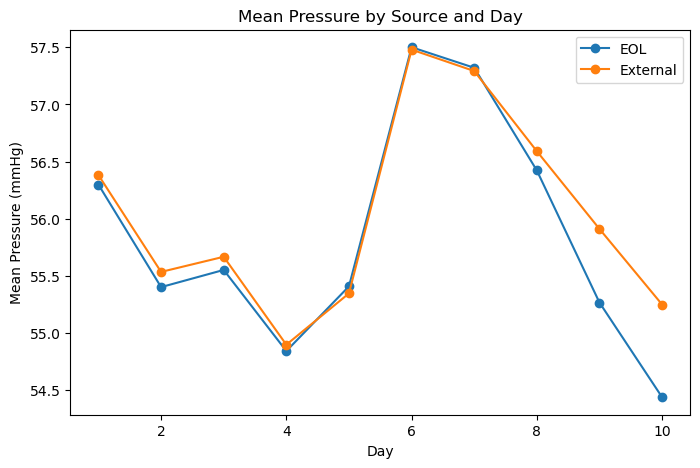

In [38]:
source_day_means = pressure_long.groupby(["day", "source"])["pressure_mmhg"].mean().unstack()

plt.figure(figsize=(8, 5))
for source in source_day_means.columns:
    plt.plot(source_day_means.index, source_day_means[source], marker="o", label=source)

plt.xlabel("Day")
plt.ylabel("Mean Pressure (mmHg)")
plt.title("Mean Pressure by Source and Day")
plt.legend()
plt.show()

## Day 6 Results Interpretation

The formal hypothesis tests show that the EOL and external systems differ significantly in paired comparisons for both pressure and flow. This indicates that the average measurement difference between the two systems is statistically detectable when the paired structure of the data is taken into account.

At the same time, the one-way ANOVA by source does not show a significant overall source effect when the paired relationship is ignored. This is consistent with the idea that the two systems are broadly similar in their overall distributions, even though paired sample-level differences are present.

The one-way ANOVA by day is statistically significant, which supports the presence of time-related effects in the EOL pressure measurements. This result is aligned with the earlier drift-oriented visualizations.

In the two-way ANOVA model with source and day, the day effect remains significant, while the source effect and source-day interaction are not significant. This suggests that time is a more important structured factor than source alone in this model.

## Day 6 Progress Summary

On Day 6, the project moved from descriptive and density-based analysis to formal statistical testing.

The main outcomes of this stage are:
- definition of explicit null and alternative hypotheses
- paired testing of the EOL and external systems
- one-way ANOVA analysis for source, channel, and day effects
- two-way ANOVA models for source-channel and source-day relationships
- integration of statistical significance with practical engineering interpretation

This stage provides the formal inferential basis for the project and prepares the way for the final decision-risk interpretation and conclusion stages.

## Day 7 Objective

The objective of Day 7 is to evaluate the practical decision risk associated with the EOL measurement system.

This stage focuses on:
- comparing EOL decisions with reference decisions
- quantifying false pass and false fail outcomes
- calculating agreement-based performance metrics
- identifying the practical consequences of measurement differences near the acceptance threshold

## Decision Risk in Measurement-Based Classification

When a measurement system is used to classify products as Pass or Fail, measurement variation can lead to decision errors. These errors are especially important when observations lie close to the acceptance threshold.

In this project, two main decision-risk outcomes are considered:

- **False pass**: the EOL system classifies a unit as Pass, while the external reference classifies it as Fail
- **False fail**: the EOL system classifies a unit as Fail, while the external reference classifies it as Pass

From an engineering perspective, false pass and false fail do not have the same practical meaning. A false pass may allow a non-conforming product to be accepted, while a false fail may reject a conforming product unnecessarily.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("synthetic_eol_measurement_data.csv")

In [6]:
confusion_table = pd.crosstab(
    df["reference_decision"],
    df["eol_decision"],
    rownames=["Reference Decision"],
    colnames=["EOL Decision"]
)

confusion_table

EOL Decision,Fail,Pass
Reference Decision,,
Fail,138,9
Pass,22,311


In [8]:
true_pass = ((df["reference_decision"] == "Pass") & (df["eol_decision"] == "Pass")).sum()
true_fail = ((df["reference_decision"] == "Fail") & (df["eol_decision"] == "Fail")).sum()
false_pass = ((df["reference_decision"] == "Fail") & (df["eol_decision"] == "Pass")).sum()
false_fail = ((df["reference_decision"] == "Pass") & (df["eol_decision"] == "Fail")).sum()

print("True Pass:", true_pass)
print("True Fail:", true_fail)
print("False Pass:", false_pass)
print("False Fail:", false_fail)

True Pass: 311
True Fail: 138
False Pass: 9
False Fail: 22


In [10]:
total = len(df)

accuracy = (true_pass + true_fail) / total
false_pass_rate = false_pass / total
false_fail_rate = false_fail / total

pass_agreement_rate = true_pass / (true_pass + false_fail) if (true_pass + false_fail) > 0 else np.nan
fail_agreement_rate = true_fail / (true_fail + false_pass) if (true_fail + false_pass) > 0 else np.nan

print("Total observations:", total)
print("Overall agreement / accuracy:", round(accuracy, 3))
print("False pass rate:", round(false_pass_rate, 3))
print("False fail rate:", round(false_fail_rate, 3))
print("Pass agreement rate:", round(pass_agreement_rate, 3))
print("Fail agreement rate:", round(fail_agreement_rate, 3))

Total observations: 480
Overall agreement / accuracy: 0.935
False pass rate: 0.019
False fail rate: 0.046
Pass agreement rate: 0.934
Fail agreement rate: 0.939


In [12]:
decision_risk_summary = pd.DataFrame({
    "Metric": [
        "Total observations",
        "True Pass",
        "True Fail",
        "False Pass",
        "False Fail",
        "Overall agreement / accuracy",
        "False pass rate",
        "False fail rate",
        "Pass agreement rate",
        "Fail agreement rate"
    ],
    "Value": [
        total,
        true_pass,
        true_fail,
        false_pass,
        false_fail,
        round(accuracy, 3),
        round(false_pass_rate, 3),
        round(false_fail_rate, 3),
        round(pass_agreement_rate, 3),
        round(fail_agreement_rate, 3)
    ]
})

decision_risk_summary

,Metric,Value
0,Total observations,480.000
1,True Pass,311.000
2,True Fail,138.000
3,False Pass,9.000
4,False Fail,22.000
5,Overall agreement / accuracy,0.935
6,False pass rate,0.019
7,False fail rate,0.046
8,Pass agreement rate,0.934
9,Fail agreement rate,0.939


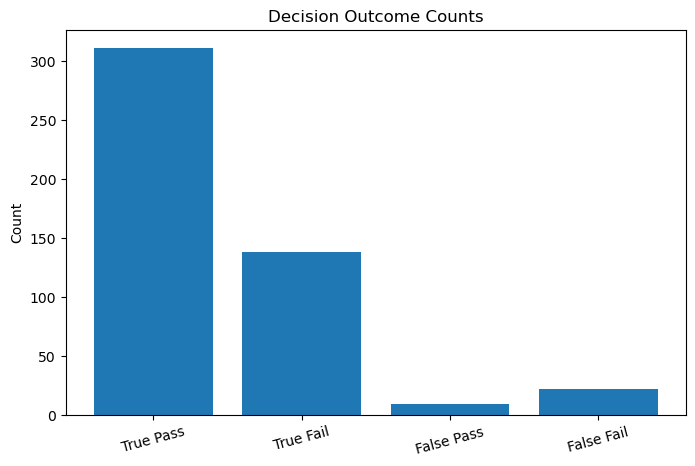

In [14]:
decision_counts = pd.Series({
    "True Pass": true_pass,
    "True Fail": true_fail,
    "False Pass": false_pass,
    "False Fail": false_fail
})

plt.figure(figsize=(8, 5))
plt.bar(decision_counts.index, decision_counts.values)
plt.ylabel("Count")
plt.title("Decision Outcome Counts")
plt.xticks(rotation=15)
plt.show()

## Decision Outcome Counts

The decision outcome chart summarizes how often the EOL system agrees or disagrees with the external reference setup. This view is useful because it connects the statistical analysis directly to the practical classification problem.

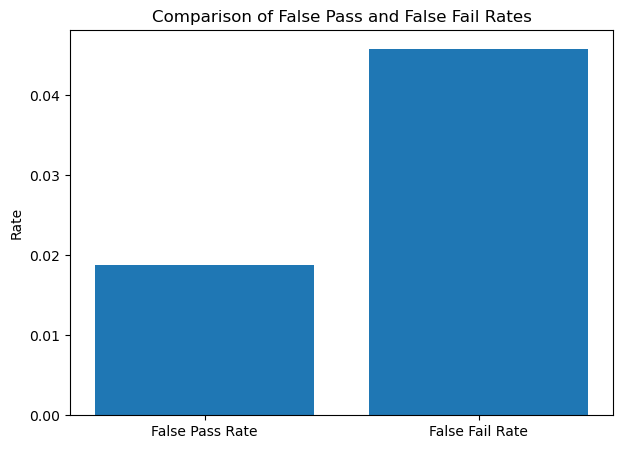

In [17]:
risk_rates = pd.Series({
    "False Pass Rate": false_pass_rate,
    "False Fail Rate": false_fail_rate
})

plt.figure(figsize=(7, 5))
plt.bar(risk_rates.index, risk_rates.values)
plt.ylabel("Rate")
plt.title("Comparison of False Pass and False Fail Rates")
plt.show()

In [19]:
near_threshold_df = df[(df["ext_pressure_mmhg"] >= 53.0) & (df["ext_pressure_mmhg"] <= 55.0)]

near_total = len(near_threshold_df)
near_false_pass = near_threshold_df["false_pass"].sum()
near_false_fail = near_threshold_df["false_fail"].sum()
near_accuracy = (
    ((near_threshold_df["reference_decision"] == near_threshold_df["eol_decision"]).sum()) / near_total
    if near_total > 0 else np.nan
)

print("Near-threshold observations:", near_total)
print("Near-threshold false pass:", near_false_pass)
print("Near-threshold false fail:", near_false_fail)
print("Near-threshold agreement:", round(near_accuracy, 3))

Near-threshold observations: 94
Near-threshold false pass: 7
Near-threshold false fail: 20
Near-threshold agreement: 0.713


In [21]:
near_threshold_summary = pd.DataFrame({
    "Metric": [
        "Near-threshold observations",
        "Near-threshold false pass",
        "Near-threshold false fail",
        "Near-threshold agreement"
    ],
    "Value": [
        near_total,
        near_false_pass,
        near_false_fail,
        round(near_accuracy, 3)
    ]
})

near_threshold_summary

,Metric,Value
0,Near-threshold observations,94.000
1,Near-threshold false pass,7.000
2,Near-threshold false fail,20.000
3,Near-threshold agreement,0.713


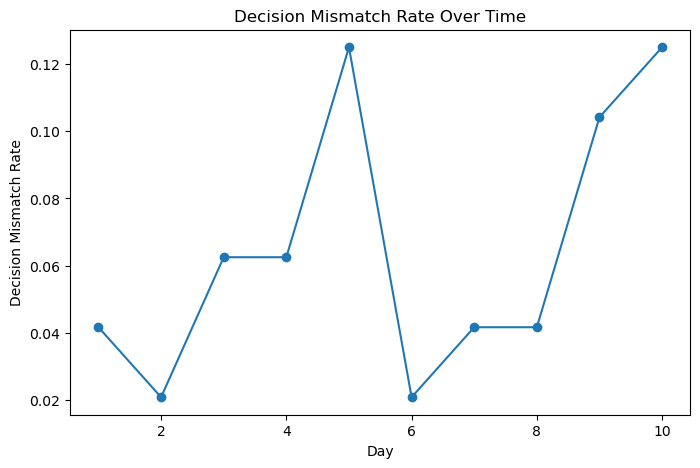

In [23]:
df["decision_mismatch"] = (df["reference_decision"] != df["eol_decision"]).astype(int)

mismatch_by_day = df.groupby("day")["decision_mismatch"].mean()

plt.figure(figsize=(8, 5))
plt.plot(mismatch_by_day.index, mismatch_by_day.values, marker="o")
plt.xlabel("Day")
plt.ylabel("Decision Mismatch Rate")
plt.title("Decision Mismatch Rate Over Time")
plt.show()

## Decision Mismatch Over Time

The day-level mismatch rate helps evaluate whether decision disagreement between the EOL system and the external reference becomes more frequent over time. This is especially relevant in the presence of drift.

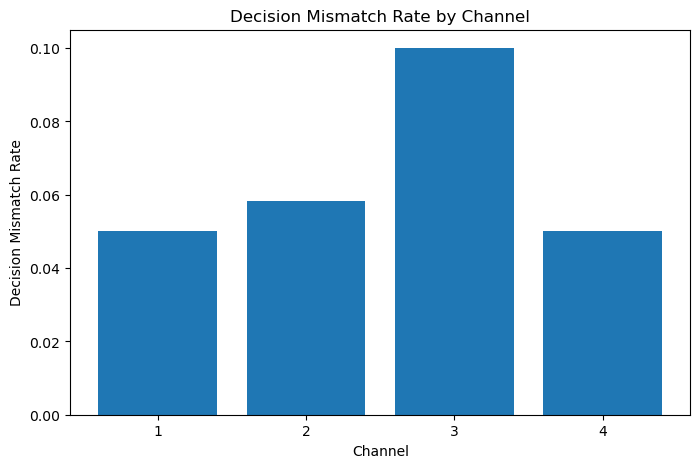

In [26]:
mismatch_by_channel = df.groupby("channel")["decision_mismatch"].mean()

plt.figure(figsize=(8, 5))
plt.bar(mismatch_by_channel.index.astype(str), mismatch_by_channel.values)
plt.xlabel("Channel")
plt.ylabel("Decision Mismatch Rate")
plt.title("Decision Mismatch Rate by Channel")
plt.show()

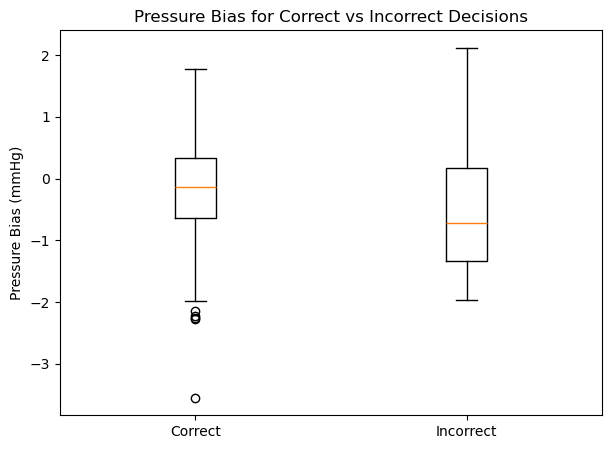

In [28]:
df["decision_correctness"] = np.where(
    df["reference_decision"] == df["eol_decision"],
    "Correct",
    "Incorrect"
)

correctness_groups = [
    df[df["decision_correctness"] == "Correct"]["pressure_bias"],
    df[df["decision_correctness"] == "Incorrect"]["pressure_bias"]
]

plt.figure(figsize=(7, 5))
plt.boxplot(correctness_groups, tick_labels=["Correct", "Incorrect"])
plt.ylabel("Pressure Bias (mmHg)")
plt.title("Pressure Bias for Correct vs Incorrect Decisions")
plt.show()

## Bias and Decision Correctness

This comparison helps show whether decision errors are associated with larger measurement bias. If incorrect decisions tend to occur together with stronger bias, then bias becomes a directly relevant driver of practical risk.

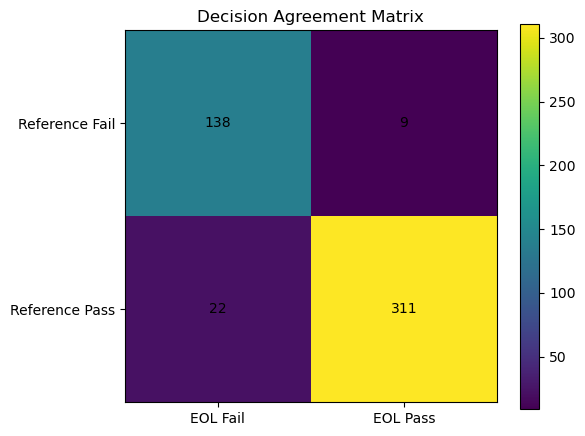

In [31]:
conf_matrix = np.array([
    [true_fail, false_pass],
    [false_fail, true_pass]
])

plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix)
plt.xticks([0, 1], ["EOL Fail", "EOL Pass"])
plt.yticks([0, 1], ["Reference Fail", "Reference Pass"])
plt.title("Decision Agreement Matrix")

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## Day 7 Interpretation

The decision-risk analysis translates the earlier statistical findings into practical product-classification consequences.

The overall agreement between the EOL system and the external reference is high, but not perfect. Both false pass and false fail outcomes are present, confirming that measurement differences can affect final Pass/Fail decisions.

The risk is especially important near the decision threshold, where relatively small measurement bias or additional variation can shift an observation from one side of the boundary to the other. In this project, false fail outcomes are more frequent than false pass outcomes, which is consistent with the slight negative pressure bias and late-stage drift previously observed in the EOL system.

## Engineering Consequences of Decision Risk

From an engineering perspective, false pass and false fail do not have the same practical consequences.

- A **false pass** may allow a non-conforming unit to be accepted, which creates quality risk.
- A **false fail** may reject a conforming unit, which creates cost, delay, and unnecessary waste.

Therefore, decision-risk analysis should not focus only on total agreement. It should also consider the type of disagreement and its practical meaning in the production environment.

## Day 7 Progress Summary

On Day 7, the project focused on decision risk and classification agreement between the EOL system and the external reference setup.

The main outcomes of this stage are:
- explicit confusion-matrix style comparison of Pass/Fail decisions
- calculation of false pass and false fail rates
- evaluation of agreement both overall and near the threshold
- visualization of decision mismatch over time and by channel
- interpretation of measurement bias as a practical driver of classification error

This stage connects the statistical analysis to the real engineering decision problem and prepares the project for final interpretation, reproducibility review, and conclusion.